In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import pickle

import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


print(os.getcwd())  # Should show the project root 

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES, REPRESENTATIVES_FOR_GOALS

from config import COLOR_SCHEME, CATEGORY_COLOURS, CATEGORY_ORDER

%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/B_pca_and_pareto_trade-off


In [2]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis")
output_folder.mkdir(exist_ok=True)


with open(output_folder / "all_datasets_precise_categories.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)

In [3]:
from utils import get_combined_colors

In [4]:
ordered_dataset_names = [
                        'hcp_schaefer_100_dataset_gnm', 
                        # 'hcp_schaefer_100_dataset', 
                        'suarez_MaMI_dataset', 
                        # 'lexis_data_young', 
                        # 'lexis_data_aging',
                        'lexis_data_developing', 
                        'kaysons_generated_networks_diffusion', 
                        'kaysons_generated_networks_propagation', 
                        'kaysons_generated_networks_routing', 
                        # 'kaysons_generated_networks_topology', 
                        ]

In [5]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name in ordered_dataset_names: 
    df = dict_with_all_datasets[dataset_name]
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology" or dataset_name == "hcp_schaefer_100_dataset": 
        print(" ---> skipped")
        continue

    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        df["color_dataset"] = get_combined_colors(df)
    
    else: 
        df["color_dataset"] = COLOR_SCHEME[dataset_name]

    huge_df = pd.concat([huge_df, df], ignore_index=True)

hcp_schaefer_100_dataset_gnm 25000
suarez_MaMI_dataset 224
lexis_data_developing 629
kaysons_generated_networks_diffusion 1
kaysons_generated_networks_propagation 1
kaysons_generated_networks_routing 1


In [6]:
len(huge_df)

25856

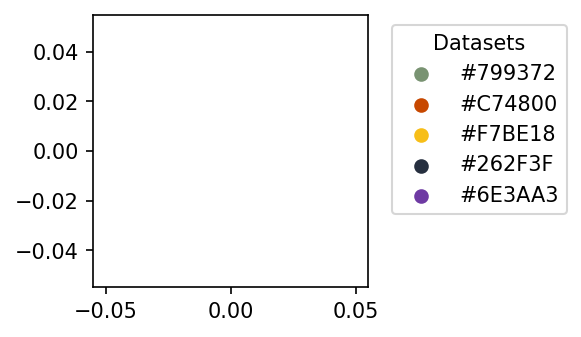

In [7]:
huge_df["color_dataset"].unique()

# plot each one dot of the colors if they are given as hex code 
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

for color in huge_df["color_dataset"][huge_df["dataset"] != "hcp_schaefer_100_dataset_gnm"].unique():
    ax.scatter([], [], color=color, label=color)

ax.legend(title="Datasets", bbox_to_anchor=(1.05, 1), loc='upper left')

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/corr_matrix_categorised.pdf


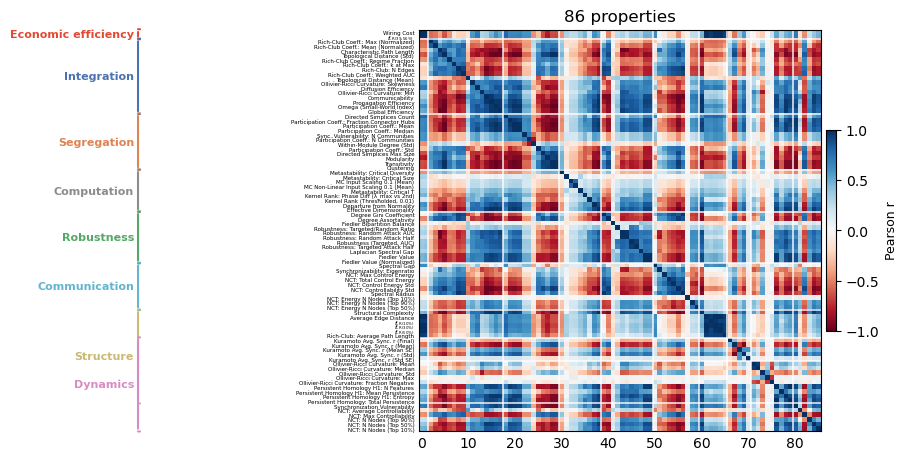

In [8]:


# For pca always drop the dataset column and only use the metric columns
huge_df_properties = huge_df.drop(columns=["dataset", "color_dataset"])

# Make a correlation axis between the columns of the huge_df. Don't use the dataset column for this, only the metric columns.
correlation_matrix = huge_df_properties.corr()

# ── 1. Load category / section metadata from Excel ────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx" # network_properties_full_excel.xlsx"   # ← adjust path if needed
meta_raw = pd.read_excel(excel_path, sheet_name=0)

meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)

# ── 2. Sort variables by category, then section ───────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]

def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, str(row["section"]))

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df_properties[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])

# Append any uncategorised variables at the end
final_order.extend([c for c in cols_in_data if c not in final_order])

# ── 4. Reorder & label ────────────────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18,12)))

gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu", vmin=-1, vmax=1,
    aspect="equal", 
    interpolation="none",
)

# White dividers between categories
boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
# ax.set_xticks(np.arange(n))
# ax.set_xticklabels(new_labels, rotation=90, fontsize=8, ha="right")
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=4)
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Category brackets on the left ─────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005 
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour  = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top   = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot   = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid   = (y_top + y_bot) / 2
    kw      = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),       xytext=(BRACKET_X, y_top),   **kw)  # vertical bar
    ax.annotate("", xy=(BRACKET_X, y_top),        xytext=(BRACKET_X+SERIF_W, y_top), **kw)  # top serif
    ax.annotate("", xy=(BRACKET_X, y_bot),        xytext=(BRACKET_X+SERIF_W, y_bot), **kw)  # bottom serif
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties", # Correlation Matrix - {n} metrics (ordered by category, clustered within)",
            #  fontsize=11, 
            #  pad=8
             )

plt.savefig(output_folder / "corr_matrix_categorised.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "corr_matrix_categorised.pdf")
plt.show()

In [9]:
huge_df_properties.columns

Index(['transitivity', 'avg_clustering', 'modularity', 'degree_gini',
       'degree_assortativity', 'omega', 'structural_complexity',
       'directed_simplices_count', 'directed_simplices_max_size', 'eta',
       'gamma', 'char_path_length', 'global_efficiency',
       'diffusion_efficiency', 'propagation_efficiency', 'avg_communicability',
       'topological_distance_mean', 'topological_distance_std',
       'avg_edge_distance', 'wiring_cost',
       'proportion_long_range_connections_0.1',
       'proportion_long_range_connections_0.3',
       'proportion_long_range_connections_0.3956',
       'proportion_long_range_connections_0.5', 'richclub_n_edges',
       'richclub_avg_length', 'rich_club_coefficient_rc_max_norm',
       'rich_club_coefficient_rc_mean_norm',
       'rich_club_coefficient_rc_k_at_max',
       'rich_club_coefficient_rc_regime_frac',
       'rich_club_coefficient_rc_weighted_auc', 'spectral_radius',
       'spectral_gap', 'synchronizability_eigenratio_eigenratio

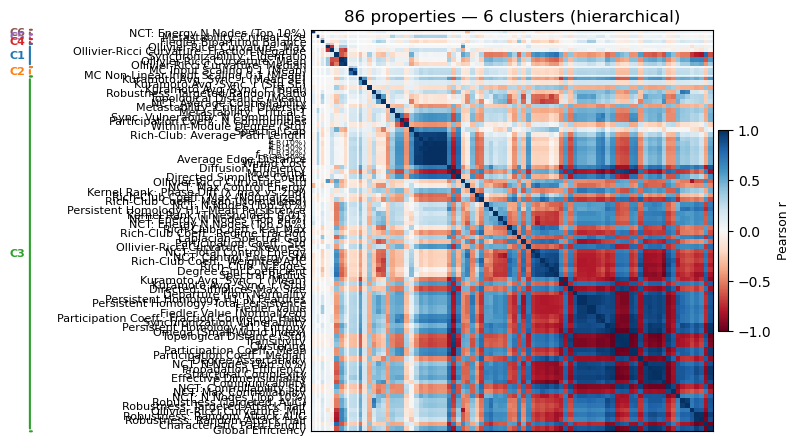


Cluster 1 (5 vars):
  Ollivier-Ricci Curvature: Max, Ollivier-Ricci Curvature: Fraction Negative, Synchronizability: Eigenratio, Ollivier-Ricci Curvature: Mean, Ollivier-Ricci Curvature: Median

Cluster 2 (2 vars):
  MC Input Scaling 0.1 (Mean), MC Non-Linear Input Scaling 0.1 (Mean)

Cluster 3 (76 vars):
  Kuramoto Avg. Sync. r (Mean SE), Kuramoto Avg. Sync. r (Std SE), Kuramoto Avg. Sync. r (Final), Robustness: Targeted/Random Ratio, Topological Distance (Mean), NCT: Average Controllability, Metastability: Critical Diversity, Metastability: Critical T, Sync. Vulnerability: N Communities, Participation Coeff.: N Communities, Within-Module Degree (Std), Spectral Gap, Rich-Club: Average Path Length, $f_{{\rm LR\,(10\%)}}$, $f_{{\rm LR\,(50\%)}}$, $f_{{\rm LR\,(30\%)}}$, $f_{{\rm LR\,(39.56\%)}}$, Average Edge Distance, Wiring Cost, Diffusion Efficiency, Modularity, Directed Simplices Count, Ollivier-Ricci Curvature: Std, NCT: Max Control Energy, Kernel Rank: Phase Diff (λ_max vs 2nd), 

In [10]:
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform

# ── 1. Full-matrix hierarchical clustering ────────────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]
corr_full    = huge_df_properties[cols_in_data].corr()

# dist = np.clip(1 - corr_full.values, 0, 2)
dist = np.clip(1 - np.abs(corr_full.values), 0, 1)  # was: 1 - corr_full.values

np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")

final_order  = [cols_in_data[i] for i in leaves_list(Z)]
reduced_corr = corr_full.loc[final_order, final_order]
new_labels   = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 2. Cut the dendrogram into N clusters & assign colours ───────────────────
N_CLUSTERS = 6  # ← tune this
cluster_ids = fcluster(Z, N_CLUSTERS, criterion="maxclust")
# fcluster returns ids in original column order, remap to final_order
orig_to_cluster = dict(zip(cols_in_data, cluster_ids))

cluster_palette = plt.cm.tab10.colors
def cluster_colour(col):
    cid = orig_to_cluster.get(col, 0)
    return cluster_palette[(cid - 1) % len(cluster_palette)]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n   = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu", vmin=-1, vmax=1,
    aspect="equal", interpolation="nearest",
)

# ── 4. White dividers between clusters ───────────────────────────────────────
prev_c = orig_to_cluster[final_order[0]]
for i, col in enumerate(final_order[1:], start=1):
    if orig_to_cluster[col] != prev_c:
        ax.axhline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
    prev_c = orig_to_cluster[col]

# ── 5. Tick labels ────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Cluster brackets on the left ──────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   =  0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

# Build row spans per cluster (in display order)
cluster_row_spans = {}
for row_i, col in enumerate(final_order):
    cid = orig_to_cluster[col]
    cluster_row_spans.setdefault(cid, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cid, (r0, r1) in cluster_row_spans.items():
    colour = cluster_palette[(cid - 1) % len(cluster_palette)]
    y_top  = row_to_y(r0, n) + 0.5 / n
    y_bot  = row_to_y(r1, n) - 0.5 / n
    y_mid  = (y_top + y_bot) / 2
    kw     = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                  arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),             xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),             xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, f"C{cid}", transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties — {N_CLUSTERS} clusters (hierarchical)")

# plt.savefig(output_folder / f"{dataset_name}_corr_matrix_clustered_automatically.pdf", bbox_inches="tight")
# print(output_folder / f"{dataset_name}_corr_matrix_clustered_automatically.pdf")
plt.show()

# ── 7. Print cluster compositions ─────────────────────────────────────────────
for cid in sorted(cluster_row_spans):
    members = [PROPERTY_NAMES.get(c, c) for c in final_order
               if orig_to_cluster[c] == cid]
    print(f"\nCluster {cid} ({len(members)} vars):")
    print("  " + ", ".join(members))


In [11]:
import re
from config import PROPERTY_NAMES

# ── Category definitions ──────────────────────────────────────────────────────
remaining_categories = {
    "Fundamental Topology": [ 
        # "transitivity", # corr too highly with avg_clustering
        # "avg_clustering", # omega
        "modularity", 
        # "degree_gini", # too high corr with spectral_radius
        # "degree_assortativity", 
        "omega", 
        # "structural_complexity", 
        
        "directed_simplices_count", # Higher order
        "directed_simplices_max_size",
        
        # "energy" # i.e.: Fit to networks - maybe remove again? 
    ],
    "Paths, Efficiency & Communication": [
        # "char_path_length", 
        "global_efficiency", # corr too highly with omega
        "diffusion_efficiency",
        "propagation_efficiency", # corr too highly with diffusion_efficiency
        # "avg_communicability", # corr too highly with spectral_radius # !!!!!!!
        # "topological_distance_mean", 
        # "topological_distance_std",
    ],
    "Spatial Embedding & Wiring Cost": [
        # "avg_edge_distance", 
        "wiring_cost",
        # "proportion_long_range_connections_0.1",
        # "proportion_long_range_connections_0.3",
        "proportion_long_range_connections_0.3956",
        # "proportion_long_range_connections_0.5",
    ],
    "Rich-Club Organization": [
        # "richclub_n_edges", 
        # "richclub_avg_length",
        # "rich_club_coefficient_rc_max_norm",
        # "rich_club_coefficient_rc_mean_norm",
        "rich_club_coefficient_rc_k_at_max",
        # "rich_club_coefficient_rc_regime_frac",
        # "rich_club_coefficient_rc_weighted_auc",
    ],
    "Spectral Properties, Algebraic Connectivity & Fiedler Analysis": [
        "spectral_radius", 
        "spectral_gap", # Has exactly the same output as Fatemehs version, bc it is identical (lambda_n - lambda_(n-1))
        "synchronizability_eigenratio_eigenratio", # lambda_n / lambda_2

        # "kernel_rank_thresholded_and_summed_0.01",          # np.sum(np.abs(eigs) > threshold * np.abs(eigs).max())
        # "kernel_rank_phase_diff_of_lambda_max_and_2nd",     # np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max())
        
        "algebraic_connectivity_fiedler_value", # Relies on a different library, I hope? 
        # "algebraic_connectivity_fiedler_value_norm",
        "algebraic_connectivity_laplacian_spectral_gap",
        # "algebraic_connectivity_fiedler_bipartition_balance",
        
        "departure_from_normality_schur",

        # "effective_dimensionality", # corr too highly with omega
    ],
    "Metastability & Kuramoto Synchronization": [ 
        "repertoire_sweep_weighted_by_distances_T_critical",
        "repertoire_sweep_weighted_by_distances_size_critical",
        "repertoire_sweep_weighted_by_distances_diversity_critical", 
        
        # "kuramoto_averaged_synchronization_r_final",
        # "kuramoto_averaged_synchronization_r_mean",
        # "kuramoto_averaged_synchronization_r_mean_se",
        # "kuramoto_averaged_synchronization_r_std",
        # "kuramoto_averaged_synchronization_r_std_se",
    ],

    "Participation Coefficient (Louvain)": [
        "participation_coefficient_n_communities",
        # "participation_coefficient_pc_mean", # corr too highly with omega
        # "participation_coefficient_pc_median",
        "participation_coefficient_pc_std",
        "participation_coefficient_pc_frac_connector", # needs to be put into relation with Q
        # "participation_coefficient_wmd_std",
    ],
    "Ollivier-Ricci Curvature": [ # If too annoying to describe, keep only one. 
        # "ollivier_ricci_curvature_orc_mean",
        # "ollivier_ricci_curvature_orc_median",
        # "ollivier_ricci_curvature_orc_std", 
        "ollivier_ricci_curvature_orc_min",
        # "ollivier_ricci_curvature_orc_max",
        "ollivier_ricci_curvature_orc_skewness",
        # "ollivier_ricci_curvature_orc_frac_neg",
    ],
    # "Persistent Homology (TDA)": [
    #     # "persistent_homology_ph_h1_n_features",
    #     # "persistent_homology_ph_h1_persistence_mean",
    #     # "persistent_homology_ph_h1_entropy",
    #     # "persistent_homology_ph_total_persistence",
    # ],

    "Targeted Attack Robustness & Community Structure & Vulnerability": [
        "targeted_attack_robustness_rob_targeted_auc",
        # "targeted_attack_robustness_rob_targeted_half",
        # "targeted_attack_robustness_rob_random_auc", # corr too highly with 'char_path_length'
        # "targeted_attack_robustness_rob_random_half",
        "targeted_attack_robustness_rob_ratio",
        
        # "community_synchronization_vulnerability_value", # too high corr with participation_coefficient_pc_frac_connector
        "community_synchronization_vulnerability_n_communities",
        ],
    "Network Control Theory - Average Controllability": [
        # "nct_control_avg",
        "nct_control_std",  
        # "nct_control_max",
        # "nct_control_n_nodes_90_percent",
        # "nct_control_n_nodes_50_percent",
        # "nct_control_n_nodes_10_percent",
    ],
    # "Network Control Theory - Control Energy": [
    #     "nct_energies_total",
    #     "nct_energies_std", 
    #     "nct_energies_max",
    #     "nct_energies_n_nodes_90_percent",
    #     "nct_energies_n_nodes_50_percent",
    #     "nct_energies_n_nodes_10_percent",
    # ],
    "Computational Capacity": [
        # "computational_capacity_memory_capacity_total",
        # "computational_capacity_memory_timescale",
        # "computational_capacity_nonlinear_capacity_total",
        # "computational_capacity_cubic_capacity_total",
        # "computational_capacity_cross_capacity_total",
        # "computational_capacity_memory_nonlinear_ratio",
        # "computational_capacity_total_capacity",
        # "computational_capacity_state_dimensionality", 
        # "computational_capacity_state_entropy",
        # "computational_capacity_state_rank",
        # "computational_capacity_separation_ratio",
        # "computational_capacity_lyapunov_exponent",
    ],
    # "Reservoir Computing - Basic Measures": 
    "Memory Capacity - Full Lag Profile": [
        # [f"mc_{i}" for i in range(1, 50)]
        # "mc_mean" # , "mc_std"]
        "mc_input_scaling_0_1_mc_mean", 
        "mc_nonlinear_input_scaling_0_1_mc_mean",
        
        "ipc_ipc_deg1_mean", # "ipc_ipc_deg1_std", 
        "ipc_ipc_deg2_mean", # "ipc_ipc_deg2_std"
            
    ],
}


precise_categories = []
for cat_name, cat_cols in remaining_categories.items(): 
    
    for col in cat_cols:
        precise_categories.append(col)


# precise_categories
len(precise_categories)

32

In [12]:
precise_categories

['modularity',
 'omega',
 'directed_simplices_count',
 'directed_simplices_max_size',
 'global_efficiency',
 'diffusion_efficiency',
 'propagation_efficiency',
 'wiring_cost',
 'proportion_long_range_connections_0.3956',
 'rich_club_coefficient_rc_k_at_max',
 'spectral_radius',
 'spectral_gap',
 'synchronizability_eigenratio_eigenratio',
 'algebraic_connectivity_fiedler_value',
 'algebraic_connectivity_laplacian_spectral_gap',
 'departure_from_normality_schur',
 'repertoire_sweep_weighted_by_distances_T_critical',
 'repertoire_sweep_weighted_by_distances_size_critical',
 'repertoire_sweep_weighted_by_distances_diversity_critical',
 'participation_coefficient_n_communities',
 'participation_coefficient_pc_std',
 'participation_coefficient_pc_frac_connector',
 'ollivier_ricci_curvature_orc_min',
 'ollivier_ricci_curvature_orc_skewness',
 'targeted_attack_robustness_rob_targeted_auc',
 'targeted_attack_robustness_rob_ratio',
 'community_synchronization_vulnerability_n_communities',
 'nct_

In [13]:
from config import PROPERTY_NAMES

# --- Config ---
THRESHOLD = 0.95  # only flag pairs above this

# Start fresh each run from the full metric set
remaining_cols = huge_df_properties.columns.tolist()
print(len(remaining_cols), "columns before removals")
# remove all columns that are not in PROPERTY_NAMES.keys(): 
remaining_cols = [c for c in remaining_cols if c in precise_categories] # PROPERTY_NAMES.keys()]
print(len(remaining_cols), "columns after removing those not in 'precise_categories'")

to_remove = [
            # "char_path_length",
            ] 

if to_remove is not None:
    remaining_cols = [c for c in remaining_cols if c not in to_remove]


# ── Run this cell repeatedly ──────────────────────────────────────────────────
working_df = huge_df_properties[remaining_cols].copy()
corr = working_df.corr().abs()

# Zero out diagonal and lower triangle to avoid duplicates
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_upper = corr.where(mask)

# Find the single highest correlation
max_corr = corr_upper.stack().max()
max_pair = corr_upper.stack().idxmax()

if max_corr < THRESHOLD:
    print(f"✅ No correlations above {THRESHOLD}. Done! {len(remaining_cols)} variables remain.")
    print(f"Removed so far: {to_remove}")
else:
    var_a, var_b = max_pair
    print(f"⚠️  Highest correlation: {max_corr:.4f}")
    print(f"   → '{var_a}'")
    print(f"   → '{var_b}'")
    print()
    
    # Show each variable's mean absolute correlation with everything else
    # (helps you decide which is more redundant)
    mean_corr_a = corr_upper[var_a].fillna(corr_upper.T[var_a]).mean()
    mean_corr_b = corr_upper[var_b].fillna(corr_upper.T[var_b]).mean()
    print(f"   Mean |corr| with others:  '{var_a}' = {mean_corr_a:.3f}  |  '{var_b}' = {mean_corr_b:.3f}")
    print(f"   (Higher mean → more redundant overall → better candidate to drop)")
    print()
    # print("👉 Add one to `to_remove`, then re-run this cell:")
    # print(f"   to_remove.append('{var_a}')   # or '{var_b}'")

# # Apply removals
# remaining_cols = [c for c in huge_df_metrics.columns if c not in to_remove]
print(f"\n🗑️  Removed so far ({len(to_remove)}): {to_remove}")
print(f"📊 Remaining variables: {len(remaining_cols)}")

92 columns before removals
32 columns after removing those not in 'precise_categories'
⚠️  Highest correlation: 0.9955
   → 'wiring_cost'
   → 'proportion_long_range_connections_0.3956'

   Mean |corr| with others:  'wiring_cost' = 0.447  |  'proportion_long_range_connections_0.3956' = 0.460
   (Higher mean → more redundant overall → better candidate to drop)


🗑️  Removed so far (0): []
📊 Remaining variables: 32


In [14]:
remaining_cols

['modularity',
 'omega',
 'directed_simplices_count',
 'directed_simplices_max_size',
 'global_efficiency',
 'diffusion_efficiency',
 'propagation_efficiency',
 'wiring_cost',
 'proportion_long_range_connections_0.3956',
 'rich_club_coefficient_rc_k_at_max',
 'spectral_radius',
 'spectral_gap',
 'synchronizability_eigenratio_eigenratio',
 'algebraic_connectivity_fiedler_value',
 'algebraic_connectivity_laplacian_spectral_gap',
 'departure_from_normality_schur',
 'repertoire_sweep_weighted_by_distances_T_critical',
 'repertoire_sweep_weighted_by_distances_size_critical',
 'repertoire_sweep_weighted_by_distances_diversity_critical',
 'participation_coefficient_n_communities',
 'participation_coefficient_pc_std',
 'participation_coefficient_pc_frac_connector',
 'ollivier_ricci_curvature_orc_min',
 'ollivier_ricci_curvature_orc_skewness',
 'targeted_attack_robustness_rob_targeted_auc',
 'targeted_attack_robustness_rob_ratio',
 'community_synchronization_vulnerability_n_communities',
 'nct_

In [15]:
# Apply the selection
huge_df_properties = huge_df_properties[remaining_cols]

In [16]:
huge_df_properties

,modularity,omega,directed_simplices_count,directed_simplices_max_size,global_efficiency,diffusion_efficiency,propagation_efficiency,wiring_cost,proportion_long_range_connections_0.3956,rich_club_coefficient_rc_k_at_max,...,ollivier_ricci_curvature_orc_min,ollivier_ricci_curvature_orc_skewness,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_ratio,community_synchronization_vulnerability_n_communities,nct_control_std,mc_input_scaling_0_1_mc_mean,mc_nonlinear_input_scaling_0_1_mc_mean,ipc_ipc_deg1_mean,ipc_ipc_deg2_mean
0,0.363236,0.341296,293.0,7.0,0.443026,0.009459,0.309668,37658.445312,0.575758,20.0,...,-1.130952,-0.435868,0.3978,0.864088,6.0,0.106030,7.738215,6.778528,7.936831,14.566582
1,0.257959,0.798096,324.0,5.0,0.491734,0.009108,0.574248,31580.988281,0.434343,14.0,...,-0.535714,0.231239,0.4446,0.910562,6.0,0.062479,9.183678,8.644353,8.260727,15.874743
2,0.248524,0.867891,343.0,4.0,0.495017,0.009134,0.621655,34700.960938,0.511111,13.0,...,-0.600000,-0.565537,0.4557,0.935268,7.0,0.044849,8.405122,7.974980,8.438971,16.497386
3,0.313943,0.622053,308.0,5.0,0.482246,0.009016,0.502807,34186.390625,0.496970,19.0,...,-1.000000,0.457045,0.4182,0.860087,8.0,0.078272,6.898468,6.569768,8.086284,15.588713
4,0.380653,0.421257,221.0,8.0,0.467778,0.008724,0.414870,22356.111328,0.183838,16.0,...,-0.833333,-0.573122,0.4322,0.893511,6.0,0.108573,7.539689,6.517755,8.213699,15.126420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25851,0.521806,0.152238,168.0,7.0,0.430569,0.008187,0.399975,32976.540595,0.432323,14.0,...,-0.944444,-0.685849,0.4128,0.869071,5.0,0.086829,8.721787,8.015111,8.208432,15.217672
25852,0.502992,0.115265,178.0,8.0,0.426209,0.008241,0.332510,35221.826121,0.484848,17.0,...,-0.765152,-0.438488,0.3991,0.847310,6.0,0.107580,8.650768,7.947190,8.048952,14.654994
25853,0.498759,0.249463,252.0,6.0,0.436818,0.008208,0.568693,17137.433375,0.236499,13.0,...,-0.672727,-0.866741,0.4755,0.992963,5.0,0.038538,9.203598,8.493449,8.443692,16.446314
25854,0.363685,0.579877,317.0,6.0,0.516431,0.009136,0.523021,23338.829758,0.148221,6.0,...,-0.346429,0.122974,0.3845,0.804831,5.0,0.133631,9.127411,8.399362,8.189830,14.099841


0


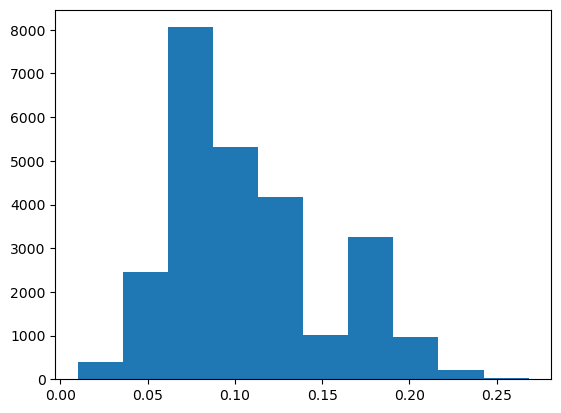

In [17]:
plt.hist(huge_df_properties["repertoire_sweep_weighted_by_distances_T_critical"])
print(huge_df_properties["repertoire_sweep_weighted_by_distances_T_critical"].isna().sum())

# REMOVE THE FOLLOWING ASAP!! 

In [18]:
# # Drop all rows that have NaN in any column 
# huge_df_properties = huge_df_properties.dropna(subset=["repertoire_sweep_weighted_by_distances_T_critical"])
# print(len(huge_df_properties))

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/corr_matrix_categorised.pdf


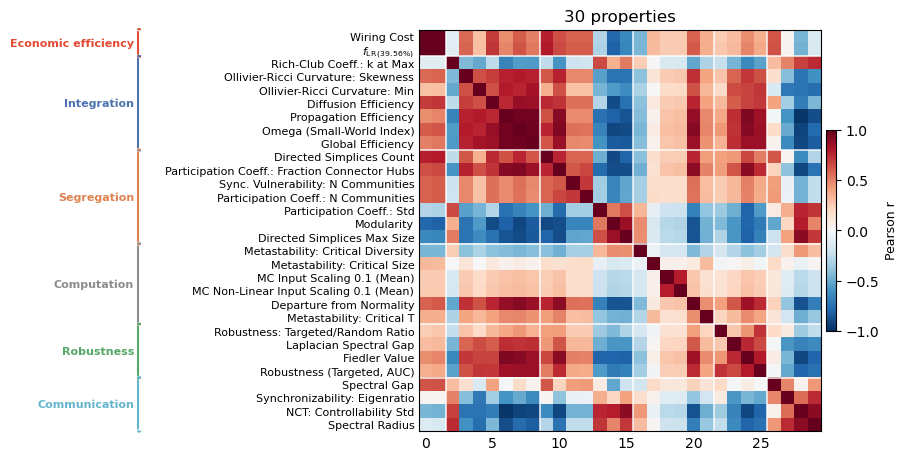

In [19]:
from config import CATEGORY_COLOURS, CATEGORY_ORDER
# ── 1. Load category / section metadata from Excel ────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx" # network_properties_full_excel.xlsx"   # ← adjust path if needed
meta_raw = pd.read_excel(excel_path, sheet_name=0)

meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)

# ── 2. Sort variables by category, then section ───────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]

def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, str(row["section"]))

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df_properties[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])

# Append any uncategorised variables at the end
final_order.extend([c for c in cols_in_data if c not in final_order])

# ── 4. Reorder & label ────────────────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18,12)))

gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu_r", vmin=-1, vmax=1,
    aspect="equal", 
    interpolation="none",
)

# White dividers between categories
boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
# ax.set_xticks(np.arange(n))
# ax.set_xticklabels(new_labels, rotation=90, fontsize=8, ha="right")
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Category brackets on the left ─────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005 
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour  = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top   = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot   = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid   = (y_top + y_bot) / 2
    kw      = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),       xytext=(BRACKET_X, y_top),   **kw)  # vertical bar
    ax.annotate("", xy=(BRACKET_X, y_top),        xytext=(BRACKET_X+SERIF_W, y_top), **kw)  # top serif
    ax.annotate("", xy=(BRACKET_X, y_bot),        xytext=(BRACKET_X+SERIF_W, y_bot), **kw)  # bottom serif
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties", # Correlation Matrix - {n} metrics (ordered by category, clustered within)",
            #  fontsize=11, 
            #  pad=8
             )

plt.savefig(output_folder / "corr_matrix_categorised.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "corr_matrix_categorised.pdf")
plt.show()

In [20]:
# final_order

In [21]:
# Turn a few properties around, such that every cluster in the correlation matrix correlates positively within itself (makes it easier to see the clusters visually, and also more intuitive to describe them as 'groups of properties that all capture a similar underlying feature')
properties_to_flip = ["rich_club_coefficient_rc_k_at_max", 
                'directed_simplices_count',
                'participation_coefficient_pc_frac_connector',
                'community_synchronization_vulnerability_n_communities',
                'participation_coefficient_n_communities',
                'repertoire_sweep_weighted_by_distances_diversity_critical']
for prop in properties_to_flip:
    if prop in huge_df_properties.columns:
        huge_df_properties[prop] = -huge_df_properties[prop]
        print(f"Flipped '{prop}'")                    

Flipped 'rich_club_coefficient_rc_k_at_max'
Flipped 'directed_simplices_count'
Flipped 'participation_coefficient_pc_frac_connector'
Flipped 'community_synchronization_vulnerability_n_communities'
Flipped 'participation_coefficient_n_communities'
Flipped 'repertoire_sweep_weighted_by_distances_diversity_critical'


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/corr_matrix_categorised_flipped.pdf


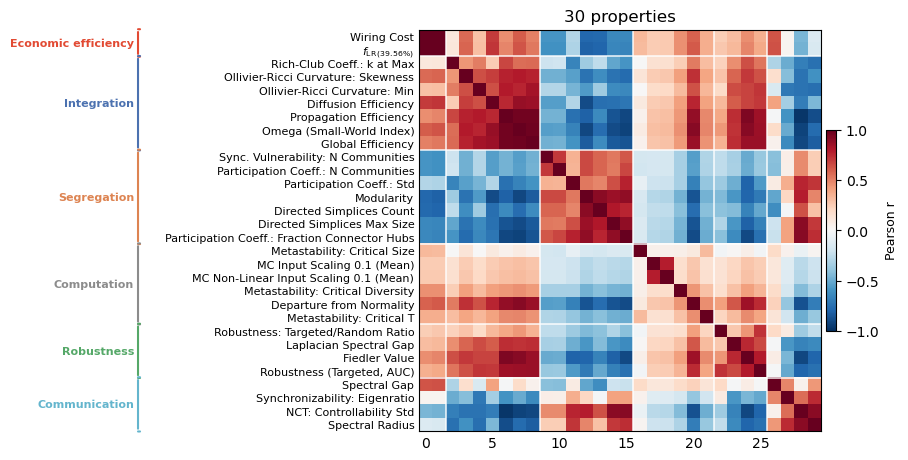

In [22]:

# ── 2. Sort variables by category, then section ───────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]

def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, str(row["section"]))

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df_properties[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])

# Append any uncategorised variables at the end
final_order.extend([c for c in cols_in_data if c not in final_order])

# ── 4. Reorder & label ────────────────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18,12)))

gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu_r", vmin=-1, vmax=1,
    aspect="equal", 
    interpolation="none",
)

# White dividers between categories
boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
# ax.set_xticks(np.arange(n))
# ax.set_xticklabels(new_labels, rotation=90, fontsize=8, ha="right")
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Category brackets on the left ─────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005 
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour  = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top   = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot   = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid   = (y_top + y_bot) / 2
    kw      = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),       xytext=(BRACKET_X, y_top),   **kw)  # vertical bar
    ax.annotate("", xy=(BRACKET_X, y_top),        xytext=(BRACKET_X+SERIF_W, y_top), **kw)  # top serif
    ax.annotate("", xy=(BRACKET_X, y_bot),        xytext=(BRACKET_X+SERIF_W, y_bot), **kw)  # bottom serif
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties", # Correlation Matrix - {n} metrics (ordered by category, clustered within)",
            #  fontsize=11, 
            #  pad=8
             )

plt.savefig(output_folder / "corr_matrix_categorised_flipped.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "corr_matrix_categorised_flipped.pdf")
plt.show()

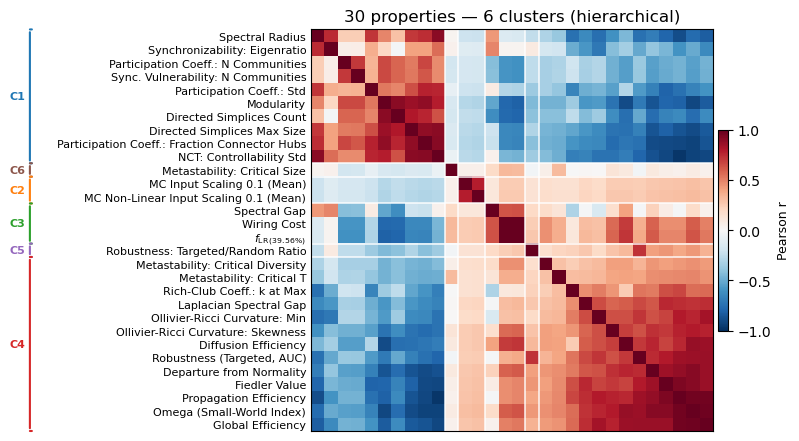


Cluster 1 (10 vars):
  Spectral Radius, Synchronizability: Eigenratio, Participation Coeff.: N Communities, Sync. Vulnerability: N Communities, Participation Coeff.: Std, Modularity, Directed Simplices Count, Directed Simplices Max Size, Participation Coeff.: Fraction Connector Hubs, NCT: Controllability Std

Cluster 2 (2 vars):
  MC Input Scaling 0.1 (Mean), MC Non-Linear Input Scaling 0.1 (Mean)

Cluster 3 (3 vars):
  Spectral Gap, Wiring Cost, $f_{{\rm LR\,(39.56\%)}}$

Cluster 4 (13 vars):
  Metastability: Critical Diversity, Metastability: Critical T, Rich-Club Coeff.: k at Max, Laplacian Spectral Gap, Ollivier-Ricci Curvature: Min, Ollivier-Ricci Curvature: Skewness, Diffusion Efficiency, Robustness (Targeted, AUC), Departure from Normality, Fiedler Value, Propagation Efficiency, Omega (Small-World Index), Global Efficiency

Cluster 5 (1 vars):
  Robustness: Targeted/Random Ratio

Cluster 6 (1 vars):
  Metastability: Critical Size


In [23]:
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform

# ── 1. Full-matrix hierarchical clustering ────────────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]
corr_full    = huge_df_properties[cols_in_data].corr()

dist = np.clip(1 - corr_full.values, 0, 2)
# dist = np.clip(1 - np.abs(corr_full.values), 0, 1)  # was: 1 - corr_full.values

np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")

final_order  = [cols_in_data[i] for i in leaves_list(Z)]
reduced_corr = corr_full.loc[final_order, final_order]
new_labels   = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 2. Cut the dendrogram into N clusters & assign colours ───────────────────
N_CLUSTERS = 6  # ← tune this
cluster_ids = fcluster(Z, N_CLUSTERS, criterion="maxclust")
# fcluster returns ids in original column order, remap to final_order
orig_to_cluster = dict(zip(cols_in_data, cluster_ids))

cluster_palette = plt.cm.tab10.colors
def cluster_colour(col):
    cid = orig_to_cluster.get(col, 0)
    return cluster_palette[(cid - 1) % len(cluster_palette)]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n   = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu_r", vmin=-1, vmax=1,
    aspect="equal", interpolation="none",
)

# ── 4. White dividers between clusters ───────────────────────────────────────
prev_c = orig_to_cluster[final_order[0]]
for i, col in enumerate(final_order[1:], start=1):
    if orig_to_cluster[col] != prev_c:
        ax.axhline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
    prev_c = orig_to_cluster[col]

# ── 5. Tick labels ────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Cluster brackets on the left ──────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   =  0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

# Build row spans per cluster (in display order)
cluster_row_spans = {}
for row_i, col in enumerate(final_order):
    cid = orig_to_cluster[col]
    cluster_row_spans.setdefault(cid, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cid, (r0, r1) in cluster_row_spans.items():
    colour = cluster_palette[(cid - 1) % len(cluster_palette)]
    y_top  = row_to_y(r0, n) + 0.5 / n
    y_bot  = row_to_y(r1, n) - 0.5 / n
    y_mid  = (y_top + y_bot) / 2
    kw     = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                  arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),             xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),             xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, f"C{cid}", transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties — {N_CLUSTERS} clusters (hierarchical)")

plt.savefig(output_folder / "corr_matrix_clustered.pdf", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Print cluster compositions ─────────────────────────────────────────────
for cid in sorted(cluster_row_spans):
    members = [PROPERTY_NAMES.get(c, c) for c in final_order
               if orig_to_cluster[c] == cid]
    print(f"\nCluster {cid} ({len(members)} vars):")
    print("  " + ", ".join(members))

In [24]:
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(scaled_data)

# plt.figure(figsize=(8,6))
# plt.scatter(x=pca_result[:,0], 
#             y=pca_result[:,1], 
#             s=2, 
#             alpha=0.4, 
#             c=huge_df['color_dataset'], 
#             # label=huge_df['dataset']
#         )
# plt.title("PCA of Metrics")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend()
# plt.tight_layout()
# plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
# plt.figure(figsize=(6,4))
# sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
# plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
#         label="Cumulative")
# plt.title("Scree Plot")
# plt.ylabel("Explained Variance Ratio")
# plt.xlabel("Principal Components")
# plt.tight_layout()
# plt.show()

Dropped columns: []


In [25]:
# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort((loadings[:, 0]))[::-1]
# sorted_indices = np.argsort(np.abs(loadings[:, 0]) + np.abs(loadings[:, 1]))[::-1]
abs_ordered_loadings = np.abs(loadings[sorted_indices, 0])
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

print("Top 30 contributors to PC1:")
for i in range(min(30, len(metric_names), len(abs_ordered_loadings))):
    print(f"     {metric_names[i]}          {abs_ordered_loadings[i]}") # : {loadings[i, 0]:.4f}")

Top 30 contributors to PC1:
     omega          0.23668970868044079
     propagation_efficiency          0.23372734297505468
     global_efficiency          0.2292489851472614
     algebraic_connectivity_fiedler_value          0.2231379007430749
     departure_from_normality_schur          0.22046749154480616
     ipc_ipc_deg2_mean          0.20428725232824438
     targeted_attack_robustness_rob_targeted_auc          0.20227966533409542
     ipc_ipc_deg1_mean          0.19849768945591137
     diffusion_efficiency          0.1962896413447311
     ollivier_ricci_curvature_orc_skewness          0.1954165829242024
     ollivier_ricci_curvature_orc_min          0.18288927507907055
     algebraic_connectivity_laplacian_spectral_gap          0.175361608719836
     proportion_long_range_connections_0.3956          0.15262691808969975
     rich_club_coefficient_rc_k_at_max          0.14834491534378424
     wiring_cost          0.14795967270365906
     repertoire_sweep_weighted_by_distances_T_cr

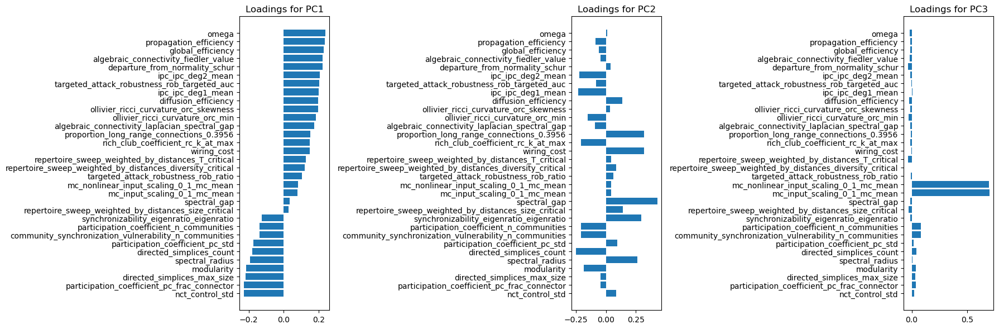

In [26]:

# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T[:, :]
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort((loadings[:, 0])) # [::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


In [27]:
for m in metric_names[::-1]: 
    print(m)

omega
propagation_efficiency
global_efficiency
algebraic_connectivity_fiedler_value
departure_from_normality_schur
ipc_ipc_deg2_mean
targeted_attack_robustness_rob_targeted_auc
ipc_ipc_deg1_mean
diffusion_efficiency
ollivier_ricci_curvature_orc_skewness
ollivier_ricci_curvature_orc_min
algebraic_connectivity_laplacian_spectral_gap
proportion_long_range_connections_0.3956
rich_club_coefficient_rc_k_at_max
wiring_cost
repertoire_sweep_weighted_by_distances_T_critical
repertoire_sweep_weighted_by_distances_diversity_critical
targeted_attack_robustness_rob_ratio
mc_nonlinear_input_scaling_0_1_mc_mean
mc_input_scaling_0_1_mc_mean
spectral_gap
repertoire_sweep_weighted_by_distances_size_critical
synchronizability_eigenratio_eigenratio
participation_coefficient_n_communities
community_synchronization_vulnerability_n_communities
participation_coefficient_pc_std
directed_simplices_count
spectral_radius
modularity
directed_simplices_max_size
participation_coefficient_pc_frac_connector
nct_contro

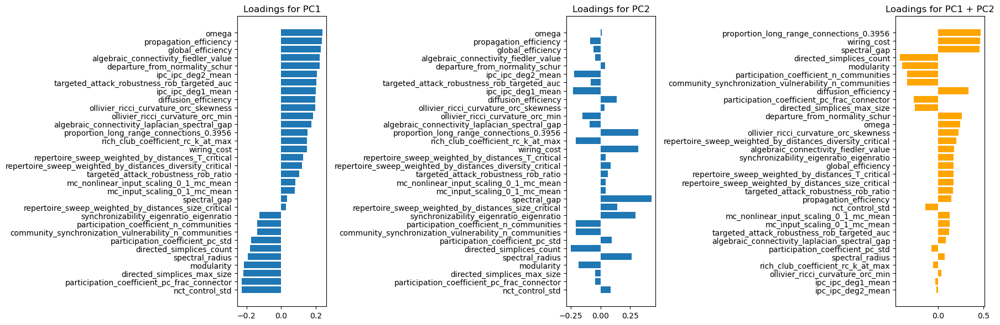

In [28]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(2):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")

# Plot 3: Addition of PC1 and PC2, ordered by magnitude of PC1+PC2
ordered_pc1_plus_pc2_indices = np.argsort(np.abs(loadings[:, 0] + loadings[:, 1])) #[::-1]
loadings = loadings[ordered_pc1_plus_pc2_indices]
metric_names = metric_names[ordered_pc1_plus_pc2_indices]
axs[2].barh(range(num_metrics), loadings[:, 0] + loadings[:, 1], color="orange")
axs[2].set_yticks(range(num_metrics))
axs[2].set_yticklabels(metric_names, rotation=0)
axs[2].set_title("Loadings for PC1 + PC2")

plt.tight_layout()
plt.show()

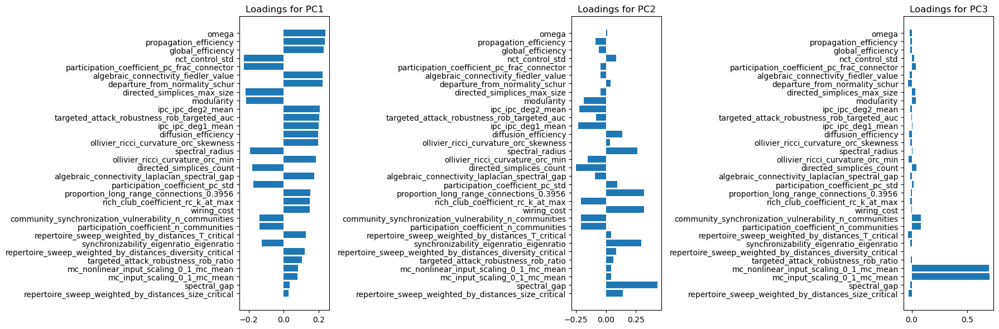

In [29]:
# Subplots of loadings for the first 3 principal components
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) #[::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()



In [30]:
# REPRESENTATIVES_FOR_GOALS = {
#     'mc_mean':                                          'Capacity (Memory)',
#     'modularity':                                       'Segregation',
#     'proportion_long_range_connections_0.3956':         'Wiring Economy',
#     'global_efficiency':                                'Integration',
#     'synchronizability_eigenratio_eigenratio':          'Synchronizability',
#     'kuramoto_synchronization_r_std':                   'Metastability',
#     'algebraic_connectivity_nx':                        'Robustness',
#     'computational_capacity_nonlinear_capacity_total':  'Capacity (Nonlinear)',
#     'repertoire_sweep_weighted_by_distances_diversity_critical': 'Repertoire Diversity',
#     'targeted_attack_robustness_rob_targeted_auc':      'Robustness (Targeted)',
# }

# rep_keys = list(REPRESENTATIVES_FOR_GOALS.keys())
# rep_labels = list(REPRESENTATIVES_FOR_GOALS.values())


In [31]:
huge_df_properties.columns, len(huge_df_properties)

(Index(['modularity', 'omega', 'directed_simplices_count',
        'directed_simplices_max_size', 'global_efficiency',
        'diffusion_efficiency', 'propagation_efficiency', 'wiring_cost',
        'proportion_long_range_connections_0.3956',
        'rich_club_coefficient_rc_k_at_max', 'spectral_radius', 'spectral_gap',
        'synchronizability_eigenratio_eigenratio',
        'algebraic_connectivity_fiedler_value',
        'algebraic_connectivity_laplacian_spectral_gap',
        'departure_from_normality_schur',
        'repertoire_sweep_weighted_by_distances_T_critical',
        'repertoire_sweep_weighted_by_distances_size_critical',
        'repertoire_sweep_weighted_by_distances_diversity_critical',
        'participation_coefficient_n_communities',
        'participation_coefficient_pc_std',
        'participation_coefficient_pc_frac_connector',
        'ollivier_ricci_curvature_orc_min',
        'ollivier_ricci_curvature_orc_skewness',
        'targeted_attack_robustness_rob_t

In [32]:
huge_df_properties.columns

Index(['modularity', 'omega', 'directed_simplices_count',
       'directed_simplices_max_size', 'global_efficiency',
       'diffusion_efficiency', 'propagation_efficiency', 'wiring_cost',
       'proportion_long_range_connections_0.3956',
       'rich_club_coefficient_rc_k_at_max', 'spectral_radius', 'spectral_gap',
       'synchronizability_eigenratio_eigenratio',
       'algebraic_connectivity_fiedler_value',
       'algebraic_connectivity_laplacian_spectral_gap',
       'departure_from_normality_schur',
       'repertoire_sweep_weighted_by_distances_T_critical',
       'repertoire_sweep_weighted_by_distances_size_critical',
       'repertoire_sweep_weighted_by_distances_diversity_critical',
       'participation_coefficient_n_communities',
       'participation_coefficient_pc_std',
       'participation_coefficient_pc_frac_connector',
       'ollivier_ricci_curvature_orc_min',
       'ollivier_ricci_curvature_orc_skewness',
       'targeted_attack_robustness_rob_targeted_auc',
    

In [33]:
# ── Helper: spider plot ───────────────────────────────────────────────────────
def make_spider(ax, values, label, color, axis_labels, title=None):
    """Draw a single radar/spider plot on a polar axis."""
    n = len(axis_labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    vals = list(values) + [values[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)
    ax.set_thetagrids(np.degrees(angles[:-1]), axis_labels, fontsize=7)
    ax.tick_params(pad=6)
    if title:
        ax.set_title(title, fontsize=9, pad=14)




selected_properties = {
    "Integration": "global_efficiency",
    "Segregation": "modularity", 
    "Wiring\neconomy": "proportion_long_range_connections_0.3956", 
    "Robustness": "targeted_attack_robustness_rob_targeted_auc", 
    "Robustness\n(lambda_2)": "algebraic_connectivity_fiedler_value",
    # "Synchronizability": ["synchronizability_eigenratio_eigenratio"], # "synchronisability", "synchronisability_normalised"],
    "Dynamics": "spectral_radius", 
    # "Computational\ncapacity": ["computational_capacity_total_capacity"], # "computational_capacity", "computational_capacity_normalised"],
    "Memory": "mc_input_scaling_0_1_mc_mean", # "computational_capacity_memory_capacity_total", # mc_mean",
    "Computational\ncapacity": "mc_nonlinear_input_scaling_0_1_mc_mean", #"computational_capacity_nonlinear_capacity_total", # CHANGE THIS!! "mc_nonlin_mean",
    # "Metastability": ["kuramoto_averaged_synchronization_r_std"], # "metastability", "metastability_normalised"],
    # "Metastability Reservoir Size": ["repertoire_sweep_weighted_by_distances_size_critical"], 
    "Metastability Reservoir Diversity": "repertoire_sweep_weighted_by_distances_diversity_critical", 

}
rep_keys   = list(selected_properties.values())
rep_labels = list(selected_properties.keys()) 
rep_idx    = [huge_df_properties.columns.get_loc(k) for k in rep_keys]

# ── Angles for spider (shared across all spider plots) ───────────────────────
n_axes   = len(rep_labels)
angles   = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles  += angles[:1]


# ── Corner point definitions ──────────────────────────────────────────────────
CORNER_COLORS = {
    "top_left":     "steelblue",
    "bottom_left":  "orange",
    "bottom_right": "forestgreen",
}

def find_corners(pca_result_2d):
    """Return a dict of corner name → row index within pca_result_2d."""
    return {
        "top_left":     int(np.argmax( pca_result_2d[:, 1])),
        "bottom_left":  int(np.argmax(-pca_result_2d[:, 0] - pca_result_2d[:, 1])),
        "bottom_right": int(np.argmax( pca_result_2d[:, 0] - pca_result_2d[:, 1])),
    }

In [34]:
# ── Corners in the full selected-properties PCA space ────────────────────────
corners_full = find_corners(pca_result)

print("Corner points (full dataset):")
for name, idx in corners_full.items():
    ds = huge_df["dataset"].iloc[idx]
    print(f"  {name}: idx={idx}, PC1={pca_result[idx,0]:.2f}, PC2={pca_result[idx,1]:.2f}, dataset={ds}")

# # ── Visualise ─────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 6))
# for ds in huge_df["dataset"].unique():
#     mask = (huge_df["dataset"] == ds).values
#     ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
#                c=huge_df[mask]["color_dataset"], # COLOR_SCHEME[ds], 
#                label=LABEL_MAP.get(ds, ds),
#                alpha=0.4, s=8, edgecolors="none")
# for name, idx in corners_full.items():
#     ax.scatter(pca_result[idx, 0], pca_result[idx, 1],
#                s=300, zorder=5, edgecolors="black", linewidths=2,
#                color=CORNER_COLORS[name])
#     ax.annotate(name, (pca_result[idx, 0], pca_result[idx, 1]),
#                 textcoords="offset points", xytext=(8, 8), fontsize=9)
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_title("PCA — Corner Points (Full Dataset)")
# ax.legend(markerscale=2, fontsize=7)
# plt.tight_layout()
# plt.show()

Corner points (full dataset):
  top_left: idx=5626, PC1=-7.38, PC2=12.52, dataset=hcp_schaefer_100_dataset_gnm
  bottom_left: idx=11127, PC1=-8.30, PC2=-1.43, dataset=hcp_schaefer_100_dataset_gnm
  bottom_right: idx=11210, PC1=6.22, PC2=-0.98, dataset=hcp_schaefer_100_dataset_gnm


In [35]:
len(huge_df)

25856

In [36]:
# ── Spider plot for the top-6 features by PC1+PC2 loading magnitude ──────────
top6_idx = np.argsort(np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2))[::-1][:6]
top6_names  = metric_names[top6_idx]
top6_labels = [n.replace("_", "\n") for n in top6_names]

In [37]:
GNM_DATASET = "hcp_schaefer_100_dataset_gnm"

# Boolean mask & original indices of non-GNM rows
# no_gnm_mask          = (huge_df["dataset"] != GNM_DATASET).values
# no_gnm_original_idx  = np.where(no_gnm_mask)[0]        # positions in sel_scaled / pca_result
# mask = no_gnm_mask
# orig_idx = no_gnm_original_idx

# Only get datasets that are mami or hcp 
mask = (huge_df["dataset"] == "lexis_data_developing").values | (huge_df["dataset"] == "suarez_MaMI_dataset").values
orig_idx = np.where(mask)[0]        # positions in sel_scaled / pca_result

# PCA results restricted to non-GNM networks
pca_result_no_gnm = pca_result[mask]

# Find corners inside the filtered view (0-indexed within the subset)
corners_no_gnm_filtered = find_corners(pca_result_no_gnm)

# ── Remap to original row indices for sel_scaled ──────────────────────────────
# Without this step, e.g. filtered_idx=5 would incorrectly retrieve row 5 of
# sel_scaled (a GNM network), not the 5th non-GNM network.
corners_no_gnm = {
    name: int(orig_idx[filt_idx])
    for name, filt_idx in corners_no_gnm_filtered.items()
}

print("Corner points (no-GNM):")
for name, orig_idx in corners_no_gnm.items():
    ds = huge_df["dataset"].iloc[orig_idx]
    filt_idx = corners_no_gnm_filtered[name]
    print(f"  {name}: filtered_idx={filt_idx}, original_idx={orig_idx}, "
          f"PC1={pca_result[orig_idx,0]:.2f}, PC2={pca_result[orig_idx,1]:.2f}, dataset={ds}")

# # ── Visualise ─────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 6))

# # Background: all datasets (GNM faded)
# for ds in huge_df["dataset"].unique():
#     mask_ds = (huge_df["dataset"] == ds).values
#     alpha = 0.15 if ds == GNM_DATASET else 0.5
#     ax.scatter(pca_result[mask_ds, 0], 
#                pca_result[mask_ds, 1],
#                c=huge_df[mask_ds]["color_dataset"], # COLOR_SCHEME[ds], 
#                label=LABEL_MAP.get(ds, ds),
#                alpha=alpha, s=8, edgecolors="none")

# # Corner markers (using original indices so they are in the correct location)
# for name, orig_idx in corners_no_gnm.items():
#     ax.scatter(pca_result[orig_idx, 0], pca_result[orig_idx, 1],
#                s=300, zorder=5, edgecolors="black", linewidths=2,
#                color=CORNER_COLORS[name])
#     ax.annotate(name, (pca_result[orig_idx, 0], pca_result[orig_idx, 1]),
#                 textcoords="offset points", xytext=(8, 8), fontsize=9)

# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_title("PCA — Corner Points (GNM excluded from search)")
# ax.legend(markerscale=2, fontsize=7)
# plt.tight_layout()
# plt.show()

Corner points (no-GNM):
  top_left: filtered_idx=65, original_idx=25065, PC1=-1.02, PC2=2.63, dataset=suarez_MaMI_dataset
  bottom_left: filtered_idx=542, original_idx=25542, PC1=-2.83, PC2=-0.83, dataset=lexis_data_developing
  bottom_right: filtered_idx=153, original_idx=25153, PC1=1.39, PC2=-1.43, dataset=suarez_MaMI_dataset


In [38]:
SPECIAL_DATASETS = [
    "kaysons_generated_networks_routing",
    "kaysons_generated_networks_diffusion",
    "kaysons_generated_networks_propagation"
]

# # Original row index for single-network datasets
special_indices = {
    ds: int(huge_df.index[huge_df["dataset"] == ds][0])
    for ds in SPECIAL_DATASETS
}


In [39]:

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
all_vals = np.concatenate([scaled_data[idx, rep_idx] for idx in all_corner_indices])
# YLIM = (np.floor(all_vals.min()) - 0.5, np.ceil(all_vals.max()) + 0.5)
YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
# YLIM = [-2, 2] # 4] # 10]
# YLIM = (-3.5, 3.5)  # override to a clean symmetric range if preferred
RING_VALS = [-2, 0, 2] # -6, 2] # 
# RING_VALS = [-1 * YLIM[0], -0.5 * YLIM[0]] + [0] + [0.5 * YLIM[1], 1 * YLIM[1]] # , -2, -1, 1, 2, YLIM[1]] # 2, 2] # [-6, 4] # , 8, 12] # [-8, -6, -4, -2, 2, 4, 6, 8, 10] # [-4, -2, 2, 4]


In [40]:
# ── Spider drawing function ────────────────────────────────────────────────────

def make_spider_standalone(values, label, color, feature_labels, title, ylim, filepath):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    # ── Limits & ticks ──
    ax.set_ylim(*ylim)
    ax.set_yticks(RING_VALS + [0]) # [-2, 0, 2])
    ax.set_yticklabels(RING_VALS + [0], fontsize=8, color="gray")

    # ── Remove outermost border ring ──
    ax.spines["polar"].set_visible(False)

    # ── Custom gridlines: draw manually so we can style zero differently ──
    ax.yaxis.grid(False)   # turn off auto y-gridlines
    ax.xaxis.grid(False)   # turn off auto x-gridlines (spokes we'll redraw)
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    for r_val in RING_VALS: # [-2, 2]:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    # Zero ring — heavier
    ax.plot(theta_ring, np.zeros(300),
            color="gray", linewidth=1.8, linestyle="-", zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

    # Spoke lines
    for angle in angles:
        ax.plot([angle, angle], YLIM, # [ylim[0], ylim[1]],
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)


    # ── Data ──
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

    # ── Feature labels (spokes) — no angle labels by default ──
    ax.set_thetagrids([])          # hide spoke degree labels; add manually below
    ax.set_xticklabels([])

    ax.set_title(title, pad=16) # , fontsize=10, pad=16, fontweight="bold")

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


# # ── Build the list of 9 panels ────────────────────────────────────────────────

# angles_for_legend = np.linspace(0, 2 * np.pi, len(rep_labels), endpoint=False).tolist()

# panels = []

# # First 6: Overall and No-GNM corners — color by *dataset* of that point
# for corner_name, orig_idx in corners_full.items():
#     ds    = huge_df["dataset"].iloc[orig_idx]
#     color = COLOR_SCHEME[ds]
#     vals  = scaled_data[orig_idx, rep_idx]
#     panels.append((f"Overall · {corner_name.replace('_',' ')}", vals, color, f"spider_overall_{corner_name}.pdf"))

# for corner_name, orig_idx in corners_no_gnm.items():
#     ds    = huge_df["dataset"].iloc[orig_idx]
#     color = COLOR_SCHEME[ds]
#     vals  = scaled_data[orig_idx, rep_idx]
#     panels.append((f"No-GNM · {corner_name.replace('_',' ')}", vals, color, f"spider_no_gnm_{corner_name}.pdf"))

# # Last 3: Special single-network datasets
# for ds_key, orig_idx in special_indices.items():
#     label = LABEL_MAP[ds_key]
#     color = COLOR_SCHEME[ds_key]
#     vals = scaled_data[orig_idx, rep_idx]
#     panels.append((f"Special · {label}", vals, color, f"spider_special_{label.lower()}.pdf"))

# # ── Save all 9 plots ──────────────────────────────────────────────────────────

# for title, vals, color, fname in panels:
#     make_spider_standalone(
#         values=vals,
#         label=title,
#         color=color,
#         feature_labels=rep_labels,
#         title=title,
#         ylim=YLIM,
#         filepath=output_folder / fname,
#     )

# print(output_folder / fname) 

In [41]:
def draw_axis_group_arcs(ax, feature_labels, angles, arc_radius, groups):
    """
    Draw a bold arc just outside the plot connecting paired spokes.
    arc_radius: draw the arc at this r value (slightly beyond local_max).
    """
    theta_dense = np.linspace(0, 2 * np.pi, 1000)

    for label_a, label_b, color in groups:
        if label_a not in feature_labels or label_b not in feature_labels:
            continue
        i_a = feature_labels.index(label_a)
        i_b = feature_labels.index(label_b)

        angle_a = angles[i_a]
        angle_b = angles[i_b]

        # Always sweep the short way between the two spokes
        if angle_b < angle_a:
            angle_a, angle_b = angle_b, angle_a

        # Choose the shorter arc
        if angle_b - angle_a > np.pi:
            arc_angles = np.linspace(angle_b, angle_a + 2 * np.pi, 80)
        else:
            arc_angles = np.linspace(angle_a, angle_b, 80)

        arc_r = np.full_like(arc_angles, arc_radius)

        ax.plot(arc_angles, arc_r,
                color=color, linewidth=3.5, solid_capstyle="round",
                zorder=0, alpha=0.85)

        # Small dots at each endpoint to cap the arc neatly
        ax.scatter([arc_angles[0], arc_angles[-1]],
                   [arc_radius, arc_radius],
                   color=color, s=18, zorder=7, alpha=0.85)


In [42]:
# ── Global y-range (shared across all plots) ──────────────────────────────────

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
all_vals = np.concatenate([scaled_data[idx, rep_idx] for idx in all_corner_indices])
# YLIM = (np.floor(all_vals.min()) - 0.5, np.ceil(all_vals.max()) + 0.5)
YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
# YLIM = [-2, 2] # 4] # 10]
# YLIM = (-3.5, 3.5)  # override to a clean symmetric range if preferred
RING_VALS = [-2, 0, 2] # -6, 2] # 
# RING_VALS = [-1 * YLIM[0], -0.5 * YLIM[0]] + [0] + [0.5 * YLIM[1], 1 * YLIM[1]] # , -2, -1, 1, 2, YLIM[1]] # 2, 2] # [-6, 4] # , 8, 12] # [-8, -6, -4, -2, 2, 4, 6, 8, 10] # [-4, -2, 2, 4]

AXIS_GROUPS = [
    ("Capacity\n(Nonlinear)", "Capacity\n(Memory)",     "lightgray"), # "#E07B39"),  # orange
    ("Robustness\n(Targeted)", "Robustness",              "lightgray"),  # "#5B8DB8"),  # blue
    ("Metastability",          "Repertoire\nDiversity",   "lightgray"),  # "#6AAB6A"),  # green
]

# ── Build the list of 9 panels ────────────────────────────────────────────────

angles_for_legend = np.linspace(0, 2 * np.pi, len(rep_labels), endpoint=False).tolist()

panels = []

# First 6: Overall and No-GNM corners — color by *dataset* of that point
for corner_name, orig_idx in corners_full.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = scaled_data[orig_idx, rep_idx]
    panels.append((f"Overall · {corner_name.replace('_',' ')}", vals, color, f"spider_overall_{corner_name}.pdf"))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = scaled_data[orig_idx, rep_idx]
    panels.append((f"No-GNM · {corner_name.replace('_',' ')}", vals, color, f"spider_no_gnm_{corner_name}.pdf"))

# Last 3: Special single-network datasets
for ds_key, orig_idx in special_indices.items():
    sp_label = LABEL_MAP[ds_key]
    color = COLOR_SCHEME[ds_key] 
    vals = scaled_data[orig_idx, rep_idx]
    panels.append((f"Special · {sp_label}", vals, color, f"spider_special_{sp_label.lower()}.pdf"))


In [43]:
# # ── Build color + label lookup for all 9 highlighted points ──────────────────
# highlighted = {}

# # First 6: corners_full and corners_no_gnm — same color logic as spider plots
# for corner_name, orig_idx in corners_full.items():
#     ds    = huge_df["dataset"].iloc[orig_idx]
#     color = COLOR_SCHEME[ds]
#     label = f"Overall · {corner_name.replace('_', ' ')}"
#     highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
#                           "source": "full"}

# for corner_name, orig_idx in corners_no_gnm.items():
#     ds    = huge_df["dataset"].iloc[orig_idx]
#     color = COLOR_SCHEME[ds]
#     label = f"No-GNM · {corner_name.replace('_', ' ')}"
#     highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
#                           "source": "no_gnm"}

# # Last 3: special datasets
# for ds_key, orig_idx in special_indices.items():
#     sp_label = LABEL_MAP[ds_key]
#     color = COLOR_SCHEME[ds_key] 
#     label = f"Special · {sp_label}"
#     highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
#                           "source": "special"}

# # ── PCA scatter — background points ──────────────────────────────────────────

# fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# for ds in huge_df["dataset"].unique():
#     mask = (huge_df["dataset"] == ds).values
#     ax.scatter(
#         pca_result[mask, 0], pca_result[mask, 1],
#         c=huge_df[mask]["color_dataset"], # COLOR_SCHEME[ds], 
#         # c=COLOR_SCHEME[ds], 
#         label=LABEL_MAP.get(ds, ds),
#         alpha=0.3, s=8, edgecolors="none", zorder=1,
#     )

# # ── Highlighted points ────────────────────────────────────────────────────────

# marker_legend = {"full": ("o", "Overall corner"), "no_gnm": ("s", "No-GNM corner"), "special": ("^", "Special network")}

# for label, info in highlighted.items():
#     idx    = info["idx"]
#     color  = info["color"]
#     # marker = info["marker"]
#     ax.scatter(
#         pca_result[idx, 0], pca_result[idx, 1],
#         color=color, # marker=marker,
#         s=50, # 220, 
#         zorder=6,
#         edgecolors="black", linewidths=1.4,
#     )
    
# ax.spines[["top", "right"]].set_visible(False)
# ax.set_xlabel("PC1") # , fontsize=10)
# ax.set_ylabel("PC2") # , fontsize=10)
# ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

# plt.tight_layout()
# plt.savefig(output_folder / "pca_highlighted_9points.pdf", dpi=150, bbox_inches="tight")



# for label, info in highlighted.items():
#     idx    = info["idx"]
#     color  = info["color"]
#     ax.annotate(
#         label,
#         (pca_result[idx, 0], pca_result[idx, 1]),
#         textcoords="offset points", xytext=(8, 6),
#         fontsize=7.5, zorder=7,
#         bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
#     )


# plt.show()
# print(output_folder / "pca_highlighted_9points.pdf")

In [44]:
sel_df_label = huge_df
sel_pca_result = pca_result
sel_scaled = scaled_data

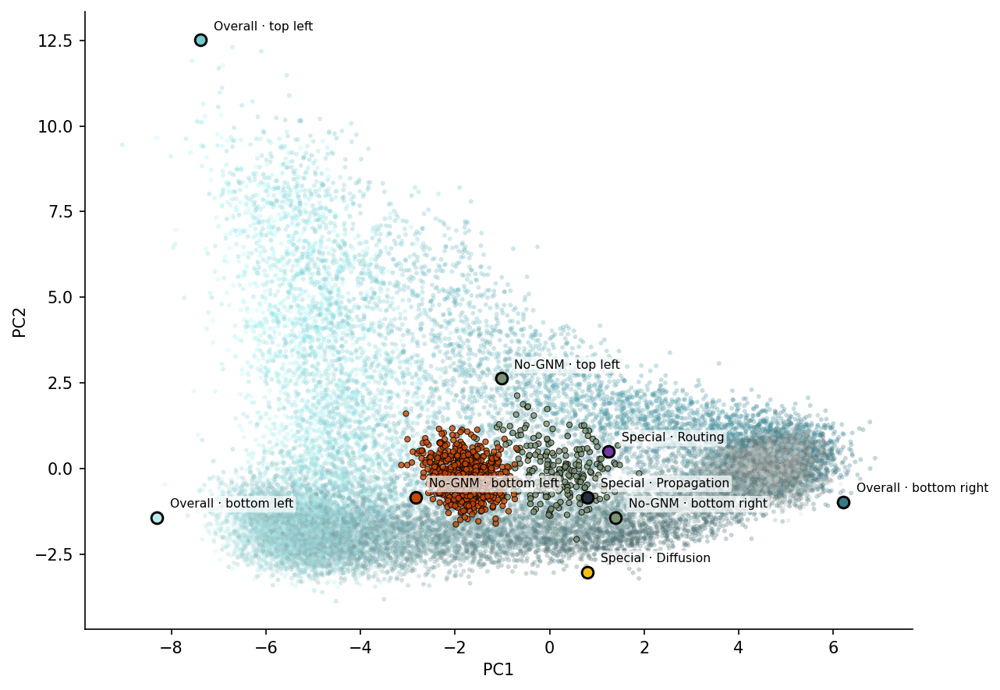

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_highlighted_9points.pdf


In [45]:

# ── Build color + label lookup for all 9 highlighted points ──────────────────
highlighted = {}

# First 6: corners_full and corners_no_gnm — same color logic as spider plots
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"Overall · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
                          "source": "full"}

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"No-GNM · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
                          "source": "no_gnm"}

# Last 3: special datasets
for ds_key, orig_idx in special_indices.items():
    sp_label = LABEL_MAP[ds_key]
    color = COLOR_SCHEME[ds_key] 
    label = f"Special · {sp_label}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
                          "source": "special"}

# ── PCA scatter — background points ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(
        sel_pca_result[mask, 0], sel_pca_result[mask, 1],
        # c=COLOR_SCHEME[ds], 
        c=huge_df[mask]["color_dataset"], # COLOR_SCHEME[ds], 
        label=LABEL_MAP.get(ds, ds),
        alpha=0.3 if ds == GNM_DATASET else 0.8, 
        s=8 if ds == GNM_DATASET else 12, 
        edgecolors="none" if ds == GNM_DATASET else "black", 
        linewidths=0 if ds == GNM_DATASET else 0.5,
        zorder=1,
    )

# ── Highlighted points ────────────────────────────────────────────────────────

marker_legend = {"full": ("o", "Overall corner"), 
                 "no_gnm": ("s", "No-GNM corner"), 
                 "special": ("^", "Special network")}

for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    # marker = info["marker"]
    ax.scatter(
        sel_pca_result[idx, 0], sel_pca_result[idx, 1],
        color=huge_df["color_dataset"].iloc[idx], # color, # marker=marker,
        s=50, # 220, 
        zorder=6,
        edgecolors="black", 
        linewidths=1.4,
    )
    
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
# ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points.pdf", dpi=150, bbox_inches="tight")



for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    ax.annotate(
        label,
        (sel_pca_result[idx, 0], sel_pca_result[idx, 1]),
        textcoords="offset points", xytext=(8, 6),
        fontsize=7.5, zorder=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )


plt.show()
print(output_folder / "pca_highlighted_9points.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_highlighted_9points_no_labels_18.pdf


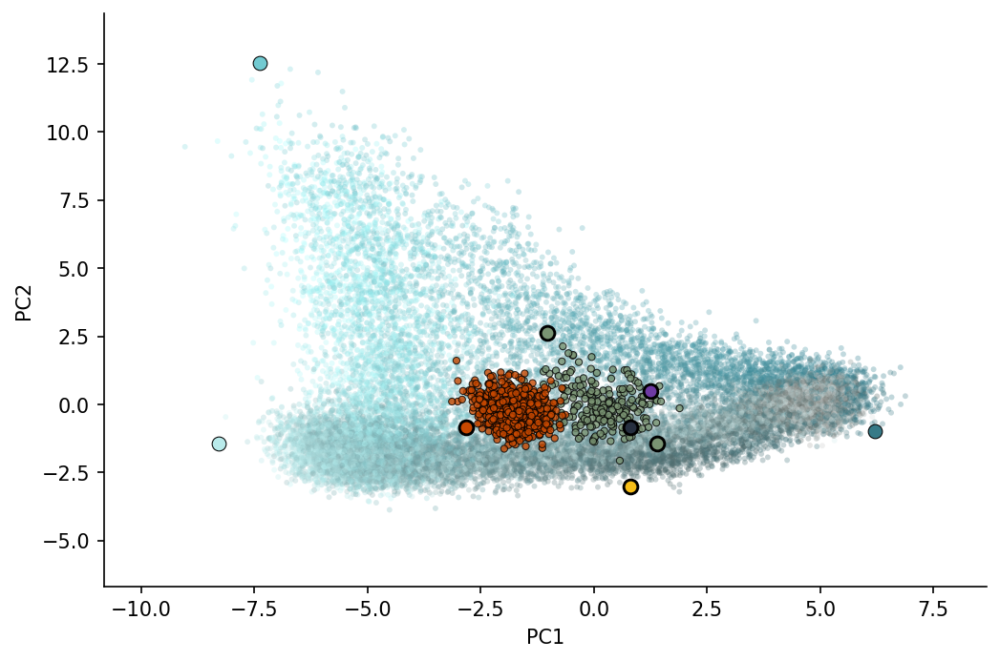

In [46]:
# ── Build color + label lookup for all 9 highlighted points ──────────────────
highlighted = {}

# First 6: corners_full and corners_no_gnm — same color logic as spider plots
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"Overall · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
                          "source": "full"}

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"No-GNM · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
                          "source": "no_gnm"}

# Last 3: special datasets
for ds_key, orig_idx in special_indices.items():
    sp_label = LABEL_MAP[ds_key]
    color = COLOR_SCHEME[ds_key]
    label = f"Special · {sp_label}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
                          "source": "special"}

# ── PCA scatter — background points ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=viz.cm_to_inch((18,12)), dpi=150)

for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(
        sel_pca_result[mask, 0], sel_pca_result[mask, 1],
        # c=COLOR_SCHEME[ds], 
        c=huge_df[mask]["color_dataset"], # COLOR_SCHEME[ds], 
        label=LABEL_MAP.get(ds, ds),
        alpha=0.3 if ds == GNM_DATASET else 0.8, 
        s=8 if ds == GNM_DATASET else 12, 
        edgecolors="none" if ds == GNM_DATASET else "black", 
        linewidths=0 if ds == GNM_DATASET else 0.5,
        zorder=1,
    )

# ── Highlighted points ────────────────────────────────────────────────────────

marker_legend = {"full": ("o", "Overall corner"), 
                 "no_gnm": ("s", "No-GNM corner"), 
                 "special": ("^", "Special network")}

for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    linewidth = 1.4 if info["source"] != "full" else 0.5
    # marker = info["marker"]
    ax.scatter(
        sel_pca_result[idx, 0], sel_pca_result[idx, 1],
        # color=color, # marker=marker,
        color=huge_df["color_dataset"].iloc[idx], # color, # marker=marker,  
        s=50, # 220, 
        zorder=6,
        edgecolors="black",
        linewidths=linewidth,
    )
    
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
# ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

# Add a bit of extra place in both axises
buffer_x = 1
buffer_y = 1
ax.set_xlim(ax.get_xlim()[0] - buffer_x, ax.get_xlim()[1] + buffer_x)
ax.set_ylim(ax.get_ylim()[0] - 2 * buffer_y, ax.get_ylim()[1] + buffer_y)

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points_no_labels_18.pdf", dpi=150, bbox_inches="tight")

print(output_folder / "pca_highlighted_9points_no_labels_18.pdf")

plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_highlighted_9points_3d.pdf


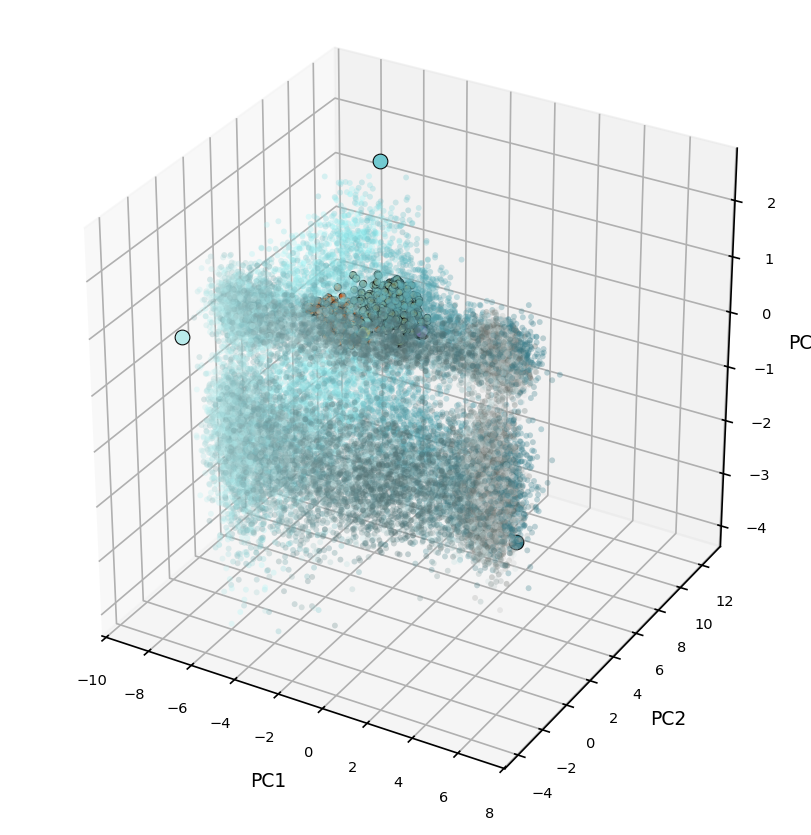

In [47]:
fig = plt.figure(figsize=viz.cm_to_inch((18, 14)), dpi=150)
ax = fig.add_subplot(111, projection="3d")

# ── Background points ─────────────────────────────────────────────────────────
for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(
        sel_pca_result[mask, 0],
        sel_pca_result[mask, 1],
        sel_pca_result[mask, 2],
        c=huge_df[mask]["color_dataset"],
        label=LABEL_MAP.get(ds, ds),
        alpha=0.3 if ds == GNM_DATASET else 0.8,
        s=8 if ds == GNM_DATASET else 12,
        edgecolors="none" if ds == GNM_DATASET else "black",
        linewidths=0 if ds == GNM_DATASET else 0.5,
        zorder=1,
        depthshade=True,
    )

# ── Highlighted points ────────────────────────────────────────────────────────
for label, info in highlighted.items():
    idx       = info["idx"]
    linewidth = 1.4 if info["source"] != "full" else 0.5
    ax.scatter(
        sel_pca_result[idx, 0],
        sel_pca_result[idx, 1],
        sel_pca_result[idx, 2],
        color=huge_df["color_dataset"].iloc[idx],
        s=50,
        zorder=6,
        edgecolors="black",
        linewidths=linewidth,
        depthshade=False,   # keep true color on highlighted points
    )

ax.set_xlabel("PC1", fontsize=9, labelpad=4)
ax.set_ylabel("PC2", fontsize=9, labelpad=4)
ax.set_zlabel("PC3", fontsize=9, labelpad=4)
ax.tick_params(labelsize=7)
ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points_3d.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "pca_highlighted_9points_3d.pdf")
plt.show()

In [48]:
import plotly.graph_objects as go

fig = go.Figure()

# ── Background points ─────────────────────────────────────────────────────────
for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    colors = huge_df[mask]["color_dataset"].tolist()
    is_gnm = ds == GNM_DATASET

    fig.add_trace(go.Scatter3d(
        x=sel_pca_result[mask, 0],
        y=sel_pca_result[mask, 1],
        z=sel_pca_result[mask, 2],
        mode="markers",
        name=LABEL_MAP.get(ds, ds),
        marker=dict(
            color=colors,
            size=2 if is_gnm else 4,
            opacity=0.3 if is_gnm else 0.8,
            line=dict(width=0) if is_gnm else dict(width=0.5, color="black"),
        ),
        hovertemplate="%{text}<extra></extra>",
        text=sel_df_label[mask].index.astype(str),
    ))

# ── Highlighted points ────────────────────────────────────────────────────────
hi_x, hi_y, hi_z, hi_colors, hi_widths, hi_labels = [], [], [], [], [], []

for label, info in highlighted.items():
    idx = info["idx"]
    hi_x.append(sel_pca_result[idx, 0])
    hi_y.append(sel_pca_result[idx, 1])
    hi_z.append(sel_pca_result[idx, 2])
    hi_colors.append(huge_df["color_dataset"].iloc[idx])
    hi_widths.append(1.4 if info["source"] != "full" else 0.5)
    hi_labels.append(label)

fig.add_trace(go.Scatter3d(
    x=hi_x, y=hi_y, z=hi_z,
    mode="markers",
    name="Highlighted",
    marker=dict(
        color=hi_colors,
        size=8,
        line=dict(color="black", width=1.5),
        symbol="circle",
    ),
    text=hi_labels,
    hovertemplate="%{text}<extra></extra>",
))

# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    width=800, height=700,
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
        xaxis=dict(showbackground=False, gridcolor="lightgrey"),
        yaxis=dict(showbackground=False, gridcolor="lightgrey"),
        zaxis=dict(showbackground=False, gridcolor="lightgrey"),
        aspectmode="cube",
    ),
    margin=dict(l=0, r=0, t=30, b=0),
    legend=dict(itemsizing="constant", font=dict(size=9)),
)

fig.write_html(output_folder / "pca_highlighted_9points_3d_interactive.html")
print(output_folder / "pca_highlighted_9points_3d_interactive.html")

fig.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_highlighted_9points_3d_interactive.html


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/huge_pca_scree_plot.pdf


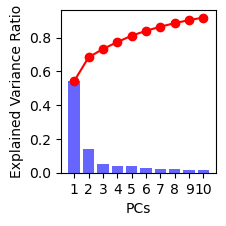

In [49]:
# plot the scree plot of explained variance ratio
plt.figure(figsize=viz.cm_to_inch((6,6)), dpi=100)
plt.bar(x=range(1, len(pca.explained_variance_ratio_) + 1), height=pca.explained_variance_ratio_, color='blue', alpha=0.6)
# add cumulative variance line
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='red', label='Cumulative Variance')

plt.xlabel('PCs')
plt.ylabel('Explained Variance Ratio')

# plt.title('Scree Plot')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.tight_layout()
plt.savefig(output_folder / "huge_pca_scree_plot.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "huge_pca_scree_plot.pdf")
plt.show()

In [50]:
from config import SELECTED_PROPERTIES_NAMES

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_mc_input_scaling_0_1_mc_mean.pdf


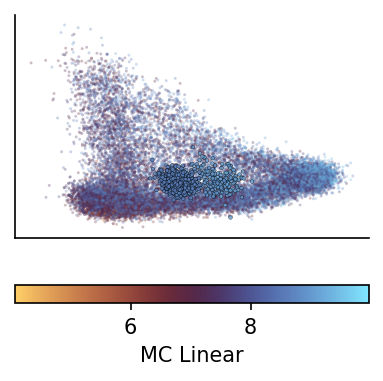

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_mc_nonlinear_input_scaling_0_1_mc_mean.pdf


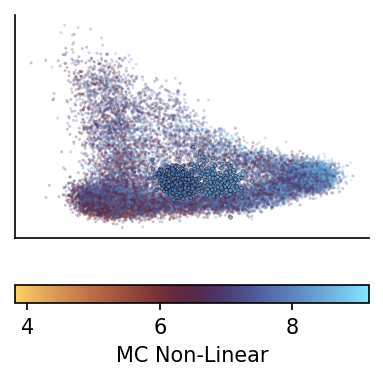

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_avg_clustering.pdf


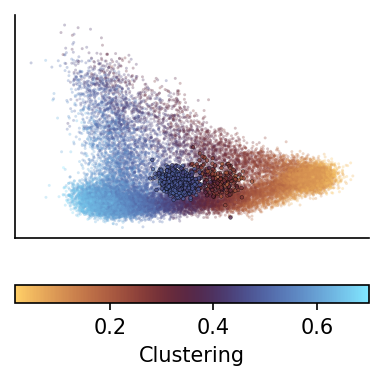

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_spectral_radius.pdf


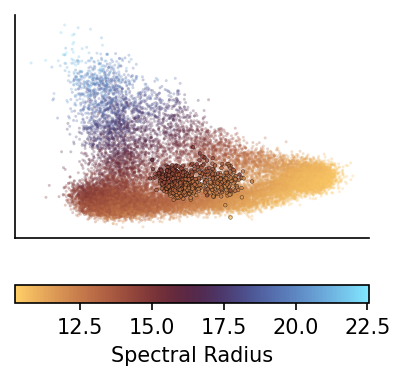

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_mc_input_scaling_0_1_mc_mean.pdf


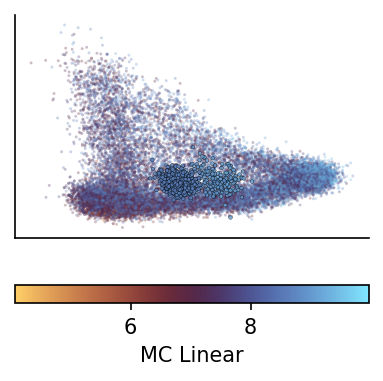

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_mc_nonlinear_input_scaling_0_1_mc_mean.pdf


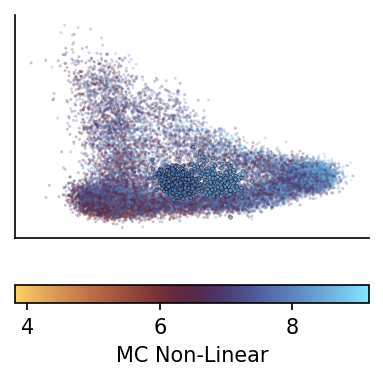

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_spectral_radius.pdf


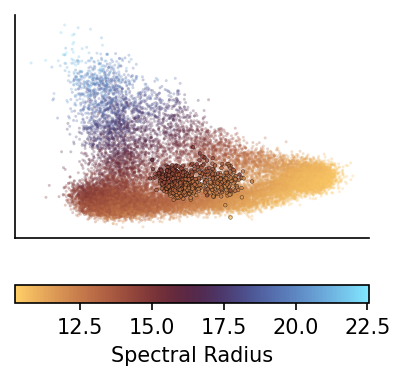

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_mc_nonlinear_input_scaling_0_1_mc_mean.pdf


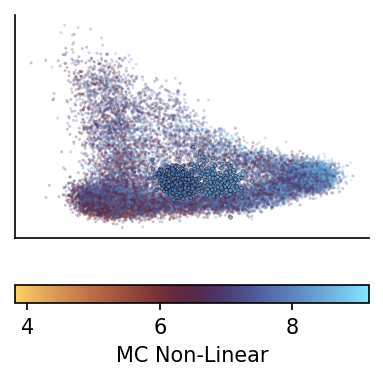

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_avg_clustering.pdf


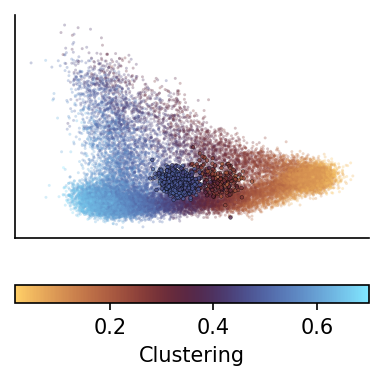

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_spectral_radius.pdf


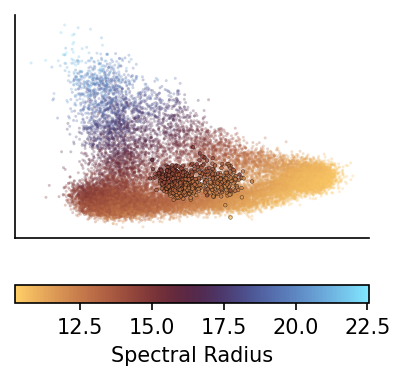

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_targeted_attack_robustness_rob_targeted_auc.pdf


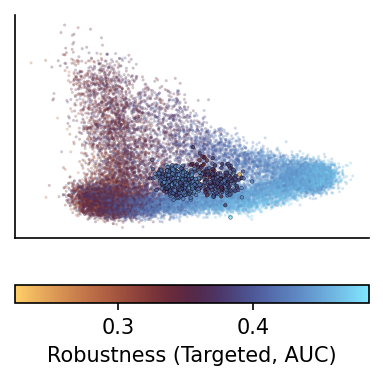

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_global_efficiency.pdf


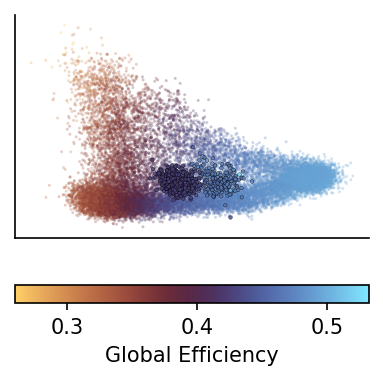

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_modularity.pdf


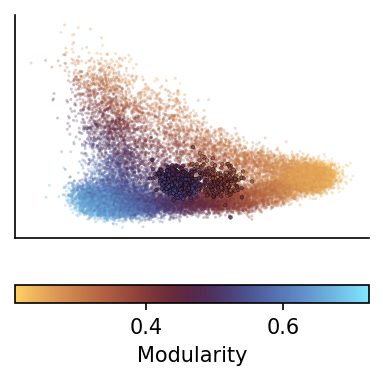

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_proportion_long_range_connections_0.3956.pdf


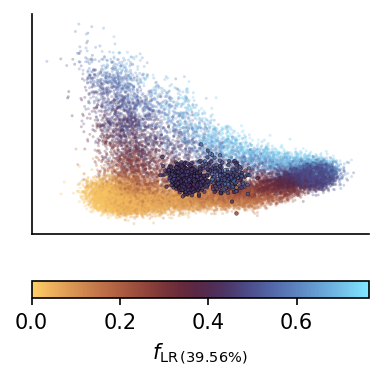

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_targeted_attack_robustness_rob_targeted_auc.pdf


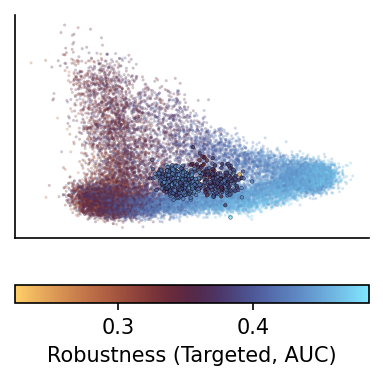

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_algebraic_connectivity_fiedler_value.pdf


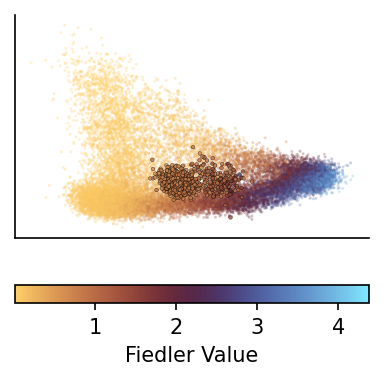

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_spectral_radius.pdf


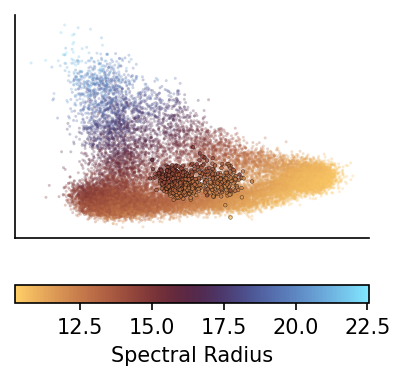

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_repertoire_sweep_weighted_by_distances_diversity_critical.pdf


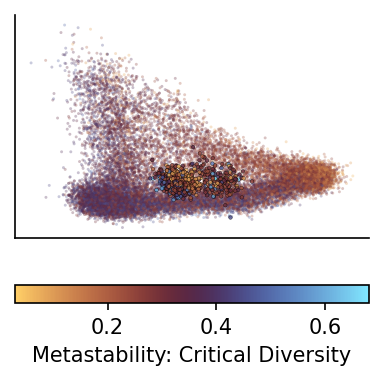

In [ ]:

measures_of_interest = ["mc_input_scaling_0_1_mc_mean",
                        "mc_nonlinear_input_scaling_0_1_mc_mean", # "mc_mean", 
                        "avg_clustering", "spectral_radius"] + [
                        "mc_input_scaling_0_1_mc_mean", "mc_nonlinear_input_scaling_0_1_mc_mean", "spectral_radius", 
                        "mc_nonlinear_input_scaling_0_1_mc_mean", 
                        "avg_clustering", "spectral_radius", "targeted_attack_robustness_rob_targeted_auc",                 
                        "global_efficiency", "modularity", 
                        "proportion_long_range_connections_0.3956", "targeted_attack_robustness_rob_targeted_auc", 
                        "algebraic_connectivity_fiedler_value", "spectral_radius", 
                        # "computational_capacity_memory_capacity_total", "computational_capacity_nonlinear_capacity_total", 
                        "repertoire_sweep_weighted_by_distances_diversity_critical"
]
# ] + precise_categories 
cmap = plt.get_cmap("managua") # cividis") # berlin")

for thing_to_be_colored in measures_of_interest:

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

    vmin, vmax = sel_df_label[thing_to_be_colored].min(), sel_df_label[thing_to_be_colored].max()
    norm = plt.Normalize(vmin, vmax)
    
    for ds in sel_df_label["dataset"].unique():
        mask = (sel_df_label["dataset"] == ds).values
        ax.scatter(
            sel_pca_result[mask, 0], sel_pca_result[mask, 1],
            # c=COLOR_SCHEME[ds], 
            # c=huge_df[mask]["color_dataset"], # COLOR_SCHEME[ds], 
            c=sel_df_label[mask][thing_to_be_colored], # color by the chosen metric instead of dataset
            cmap=cmap,
            label=LABEL_MAP.get(ds, ds),
            alpha=0.3 if ds == GNM_DATASET else 0.8, 
            s=2 if ds == GNM_DATASET else 3, 
            edgecolors="none" if ds == GNM_DATASET else "black", 
            linewidths=0 if ds == GNM_DATASET else 0.2,
            zorder=1,
            norm=norm
        )
        
    ax.spines[["top", "right"]].set_visible(False)
    # ax.set_xlabel("PC1") # , fontsize=10)
    # ax.set_ylabel("PC2") # , fontsize=10)
    ax.set_xticks([]) # Hide x-axis ticks for cleaner look
    ax.set_yticks([]) # Hide y-axis ticks for cleaner look
    # plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), 
    #              ax=ax, 
    #              label=SELECTED_PROPERTIES_NAMES[thing_to_be_colored] if thing_to_be_colored in SELECTED_PROPERTIES_NAMES else thing_to_be_colored,
    #             #  label=PROPERTY_NAMES[thing_to_be_colored], 
    #              orientation='horizontal')
    
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, 
                 label=SELECTED_PROPERTIES_NAMES.get(thing_to_be_colored, thing_to_be_colored),
                 orientation='horizontal')
    
    # ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

    plt.tight_layout(pad=0.01)
    plt.savefig(output_folder / f"pca_colored_by_{thing_to_be_colored}.pdf", dpi=150) # , bbox_inches="tight")
    print(output_folder / f"pca_colored_by_{thing_to_be_colored}.pdf")
    plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_mc_input_scaling_0_1_mc_mean_vertical_colorbar.pdf


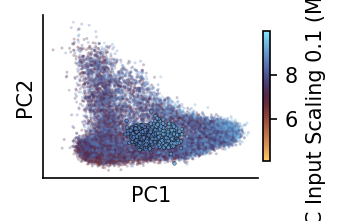

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_mc_nonlinear_input_scaling_0_1_mc_mean_vertical_colorbar.pdf


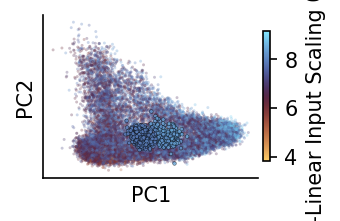

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_avg_clustering_vertical_colorbar.pdf


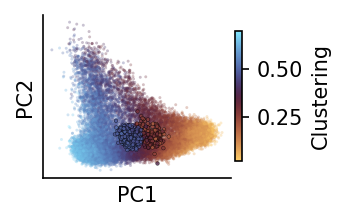

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_colored_by_spectral_radius_vertical_colorbar.pdf


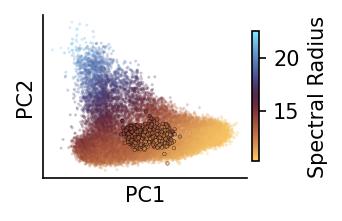

In [52]:
measures_of_interest = ["mc_input_scaling_0_1_mc_mean",
                        "mc_nonlinear_input_scaling_0_1_mc_mean", # "mc_mean", 
                        "avg_clustering", "spectral_radius"]

for thing_to_be_colored in measures_of_interest:

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,4)), dpi=150)

    vmin = sel_df_label[thing_to_be_colored].min()
    vmax = sel_df_label[thing_to_be_colored].max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for ds in sel_df_label["dataset"].unique():
        mask = (sel_df_label["dataset"] == ds).values
        ax.scatter(
            sel_pca_result[mask, 0], sel_pca_result[mask, 1],
            c=sel_df_label[mask][thing_to_be_colored],
            cmap=cmap,
            norm=norm,                          # <-- apply norm here too
            label=LABEL_MAP.get(ds, ds),
            alpha=0.3 if ds == GNM_DATASET else 0.8, 
            s=2 if ds == GNM_DATASET else 3, 
            edgecolors="none" if ds == GNM_DATASET else "black", 
            linewidths=0 if ds == GNM_DATASET else 0.2,
            zorder=1,
        )
        
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("PC1") # , fontsize=10)
    ax.set_ylabel("PC2") # , fontsize=10)
    plt.colorbar(
        plt.cm.ScalarMappable(cmap=cmap, norm=norm),  # <-- real values via norm
        ax=ax,
        label=PROPERTY_NAMES[thing_to_be_colored],
        shrink=0.8,   # <-- smaller cbar (fraction of axes height)
        pad=0.02,
    )

    plt.tight_layout()
    plt.savefig(output_folder / f"pca_colored_by_{thing_to_be_colored}_vertical_colorbar.pdf", dpi=150, bbox_inches="tight")
    print(output_folder / f"pca_colored_by_{thing_to_be_colored}_vertical_colorbar.pdf")
    plt.show()

In [53]:
from sklearn.metrics import pairwise_distances

In [54]:
COLOR_SCHEME

{'hcp_schaefer_100_dataset_gnm': '#232324',
 'hcp_schaefer_100_dataset': '#4BAE6A',
 'kaysons_generated_networks_diffusion': '#F7BE18',
 'kaysons_generated_networks_propagation': '#262F3F',
 'kaysons_generated_networks_routing': '#6E3AA3',
 'kaysons_generated_networks_topology': '#394D73',
 'suarez_MaMI_dataset': '#799372',
 'lexis_data_young': '#BD3B1A',
 'lexis_data_aging': '#5E1E0C',
 'lexis_data_developing': '#C74800',
 'lexis_data_developing_consensus_per_age_1_year': '#A6587C',
 'lexis_data_young_consensus_per_age_1_year': '#5DC400',
 'lexis_data_aging_consensus_per_age_1_year': '#E8D43C',
 'lexis_data_all_consensus_per_age_1_year': '#4BAE6A',
 'lexis_data_all_consensus_per_age_2_year': '#4BAE6A'}

In [55]:
dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].keys()

Index(['transitivity', 'avg_clustering', 'modularity', 'degree_gini',
       'degree_assortativity', 'omega', 'structural_complexity',
       'directed_simplices_count', 'directed_simplices_max_size', 'eta',
       'gamma', 'char_path_length', 'global_efficiency',
       'diffusion_efficiency', 'propagation_efficiency', 'avg_communicability',
       'topological_distance_mean', 'topological_distance_std',
       'avg_edge_distance', 'wiring_cost',
       'proportion_long_range_connections_0.1',
       'proportion_long_range_connections_0.3',
       'proportion_long_range_connections_0.3956',
       'proportion_long_range_connections_0.5', 'richclub_n_edges',
       'richclub_avg_length', 'rich_club_coefficient_rc_max_norm',
       'rich_club_coefficient_rc_mean_norm',
       'rich_club_coefficient_rc_k_at_max',
       'rich_club_coefficient_rc_regime_frac',
       'rich_club_coefficient_rc_weighted_auc', 'spectral_radius',
       'spectral_gap', 'synchronizability_eigenratio_eigenratio

# Quivers and Spider Plots 

In [64]:
# ── 1. Load category / section metadata from Excel ────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx" # network_properties_full_excel.xlsx"   # ← adjust path if needed
meta_raw = pd.read_excel(excel_path, sheet_name=0)

meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)
meta

,Category,section
var,,
transitivity,Segregation,Basic Topology
avg_clustering,Segregation,Basic Topology
modularity,Segregation,Basic Topology
degree_gini,Robustness,Basic Topology
degree_assortativity,Robustness,Basic Topology
...,...,...
computational_capacity_lyapunov_exponent,Dynamics,Reservoir Computing — Comprehensive Capacity
mc_input_scaling_0_1_mc_mean,Computation,Reservoir Computing — Comprehensive Capacity
mc_nonlinear_input_scaling_0_1_mc_mean,Computation,Reservoir Computing — Comprehensive Capacity


In [65]:
# only get those rows in meta that are in feature_cols 
feature_cols = list(huge_df_properties.columns)
meta = meta.loc[feature_cols]
meta

,Category,section
var,,
modularity,Segregation,Basic Topology
omega,Integration,Basic Topology
directed_simplices_count,Segregation,Higher-Order Topology
directed_simplices_max_size,Segregation,Higher-Order Topology
global_efficiency,Integration,"Paths, Efficiency & Communication"
diffusion_efficiency,Integration,"Paths, Efficiency & Communication"
propagation_efficiency,Integration,"Paths, Efficiency & Communication"
wiring_cost,Economic efficiency,Spatial Embedding & Wiring Cost
proportion_long_range_connections_0.3956,Economic efficiency,Spatial Embedding & Wiring Cost


In [66]:
meta["Category"].values

array(['Segregation', 'Integration', 'Segregation', 'Segregation',
       'Integration', 'Integration', 'Integration', 'Economic efficiency',
       'Economic efficiency', 'Integration', 'Communication',
       'Communication', 'Communication', 'Robustness', 'Robustness',
       'Computation', 'Computation', 'Computation', 'Computation',
       'Segregation', 'Segregation', 'Segregation', 'Integration',
       'Integration', 'Robustness', 'Robustness', 'Segregation',
       'Communication', 'Computation', 'Computation', 'Computation',
       'Computation'], dtype=object)

In [67]:
meta.value_counts("Category")

Category
Computation            8
Integration            7
Segregation            7
Communication          4
Robustness             4
Economic efficiency    2
Name: count, dtype: int64

In [68]:
from config import CATEGORY_COLOURS, CATEGORY_ORDER

In [69]:
# ── 0. Build category-aggregated values for all networks ─────────────────────
# `feature_cols`: the list of column names corresponding to columns of sel_scaled
# (e.g. the same list used to build sel_scaled / huge_df_properties columns)

cat_order_present = [c for c in CATEGORY_ORDER if c in meta["Category"].values]

def get_cat_values(row_vals: np.ndarray, feature_cols: list, cat_order: list) -> np.ndarray:
    """Return mean of z-scored feature values within each category (one value per cat)."""
    result = []
    for cat in cat_order:
        cols = [c for c in feature_cols if c in meta.index and meta.loc[c, "Category"] == cat]
        if not cols:
            result.append(np.nan)
            continue
        idxs = [feature_cols.index(c) for c in cols]
        result.append(np.nanmean(row_vals[idxs]))
    return np.array(result)

cat_labels      = cat_order_present
cat_axis_colors = [CATEGORY_COLOURS.get(c, "#444444") for c in cat_order_present]

from scipy.stats import zscore

cat_scaled_all = np.array([
    get_cat_values(sel_scaled[i], feature_cols, cat_order_present)
    for i in range(len(sel_scaled))
])

# Re-z-score each category column across all networks
cat_scaled_all = np.apply_along_axis(zscore, 0, cat_scaled_all)

cat_ylim = (np.nanmin(cat_scaled_all), np.nanmax(cat_scaled_all))
cat_labels

['Economic efficiency',
 'Integration',
 'Segregation',
 'Computation',
 'Robustness',
 'Communication']

In [105]:
cat_scaled_all

array([[ 1.14245245, -0.22209278,  0.47814123, -0.56870869, -0.51259684,
         0.55879354],
       [ 0.41546673,  0.91325703, -0.60580921,  0.98592835,  0.92377087,
        -0.45614249],
       [ 0.79847137,  0.7923974 , -1.0012038 ,  0.92735207,  1.05288084,
        -0.77918752],
       ...,
       [-0.98763086,  0.13975255,  0.51750035,  0.69807986,  0.93836201,
        -1.32081882],
       [-0.79200768,  1.25971623,  0.25397068,  0.49210912, -0.09114497,
         0.75204456],
       [-0.28409913,  1.66582467, -0.95963348,  0.10175562, -2.37372341,
         0.92882649]], shape=(25856, 6))

In [104]:
cat_order_present

['Economic efficiency',
 'Integration',
 'Segregation',
 'Computation',
 'Robustness',
 'Communication']

In [101]:
get_cat_values(sel_scaled[i], feature_cols, cat_order_present)

array([ 0.79758193,  0.68989065, -0.83964639,  0.57939523,  0.88439201,
       -0.62640304])

In [70]:
cat_order_present

['Economic efficiency',
 'Integration',
 'Segregation',
 'Computation',
 'Robustness',
 'Communication']

In [71]:
feature_cols

['modularity',
 'omega',
 'directed_simplices_count',
 'directed_simplices_max_size',
 'global_efficiency',
 'diffusion_efficiency',
 'propagation_efficiency',
 'wiring_cost',
 'proportion_long_range_connections_0.3956',
 'rich_club_coefficient_rc_k_at_max',
 'spectral_radius',
 'spectral_gap',
 'synchronizability_eigenratio_eigenratio',
 'algebraic_connectivity_fiedler_value',
 'algebraic_connectivity_laplacian_spectral_gap',
 'departure_from_normality_schur',
 'repertoire_sweep_weighted_by_distances_T_critical',
 'repertoire_sweep_weighted_by_distances_size_critical',
 'repertoire_sweep_weighted_by_distances_diversity_critical',
 'participation_coefficient_n_communities',
 'participation_coefficient_pc_std',
 'participation_coefficient_pc_frac_connector',
 'ollivier_ricci_curvature_orc_min',
 'ollivier_ricci_curvature_orc_skewness',
 'targeted_attack_robustness_rob_targeted_auc',
 'targeted_attack_robustness_rob_ratio',
 'community_synchronization_vulnerability_n_communities',
 'nct_

In [72]:
RING_VALS = [-2,2,4,6]
YLIM = [-4, 7]
COLOR = "gray" # lightgray 

In [73]:
# ── 1. Updated spider function: axes = categories, labels colored per-category ─

# def make_spider_standalone(values, label, color, feature_labels, title, ylim,
#                            filepath, neighbour_vals_list=None,
#                            axis_colors=None):          # ← NEW
def make_spider_standalone(values, label, color, feature_labels, title, ylim,
                           filepath, neighbour_vals_list=None,
                           axis_colors=None, ring_vals=None):
    n = len(values)
    angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]
    
    print(max(vals_closed))
    ring_color = "gray"
    if max(vals_closed) > 4:
        ring_colors = [ring_color] * 4
        tick_labels = ["-2", "0", "2", "4", "6"]
        y_max_change = 0 
    elif max(vals_closed) > 2:
        ring_colors = [ring_color] * 3 + ["white"]
        tick_labels = ["-2", "0", "2", "4", ""]
        y_max_change = 2
    else:
        ring_colors = [ring_color] * 2 + ["white"] * 2
        tick_labels = ["-2", "0", "2", "", ""]
        y_max_change = 4

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), subplot_kw=dict(polar=True), dpi=100)
    ax.set_ylim(*ylim) # y_max)
    # ax.set_ylim(ylim[0], ylim[1]-y_max_change) # y_max)
    print(*ylim)
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    theta_ring = np.linspace(0, 2 * np.pi, 300)

    # Gridlines
    ring_vals = ring_vals if ring_vals is not None else RING_VALS
    for i, r_val in enumerate(ring_vals):   
        ax.plot(theta_ring, np.full(300, r_val),
                color=ring_colors[i], linewidth=0.5, # 0.6, 
                linestyle="--", zorder=0)
        ax.yaxis.set_ticklabels(labels=tick_labels, 
                                fontdict={'verticalalignment': 'baseline',
                                'horizontalalignment': 'left'}) # center'}) # label_position("right")

    ax.plot(theta_ring, np.zeros(300),
            color=axis_colors, linewidth=1, # 1.8, 
            linestyle="-", zorder=1)
    
    for angle in angles:
        ax.plot([angle, angle], [ylim[0], ylim[1]-y_max_change], # ylim,
                color=axis_colors, linewidth=0.5, # 0.5, 
                linestyle="--", zorder=0)

    # Neighbour lines
    alpha_fill = 0.05
    linewidth  = 1
    zorder     = 3
    if neighbour_vals_list is not None:
        for nb_vals in neighbour_vals_list:
            nb_closed = list(nb_vals) + [nb_vals[0]]
            ax.plot(angles_closed, nb_closed,
                    color=color, #  if not "Overall" in label else "black", 
                    linewidth=linewidth, 
                    alpha=1, # 0.25, 
                    zorder=zorder + 1)
            ax.fill(angles_closed, nb_closed,
                    color=color, alpha=alpha_fill, zorder=zorder)

    # Main polygon
    ax.fill(angles_closed, vals_closed, color=color, alpha=alpha_fill, zorder=zorder)
    ax.plot(angles_closed, vals_closed,
            color="black", # color if not "Overall" in label else "black", 
            linewidth=linewidth, zorder=zorder + 1)

    # # ── Category axis labels, colored per category ────────────────────────────
    # ax.set_thetagrids(np.degrees(angles), labels=feature_labels, fontsize=7)
    # for i, (label_text, angle) in enumerate(zip(feature_labels, angles)):
    #     lbl_color = axis_colors[i] if axis_colors is not None else "black"
    #     # Find the Text object matplotlib just created and recolor it
    #     for txt in ax.get_xticklabels():
    #         if txt.get_text() == label_text:
    #             txt.set_color(lbl_color)
    #             txt.set_fontweight("bold")
    #             break
    # Remove labels 
    ax.set_thetagrids([])   

    # x ticks should be gray
    ax.tick_params(axis='y', labelcolor=axis_colors) # , labelsize=7)

    ax.set_title(title) # , pad=16, fontsize=9)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(filepath)

In [74]:
sel_df_label

,transitivity,avg_clustering,modularity,degree_gini,degree_assortativity,omega,structural_complexity,directed_simplices_count,directed_simplices_max_size,eta,...,nct_energies_n_nodes_50_percent,nct_energies_n_nodes_10_percent,mc_input_scaling_0_1_mc_mean,mc_nonlinear_input_scaling_0_1_mc_mean,ipc_ipc_deg1_mean,ipc_ipc_deg1_std,ipc_ipc_deg2_mean,ipc_ipc_deg2_std,dataset,color_dataset
0,0.325354,0.360510,0.363236,0.337838,0.262612,0.341296,0.765869,293.0,7.0,1.204082,...,17.0,2.0,7.738215,6.778528,7.936831,0.043652,14.566582,0.964144,hcp_schaefer_100_dataset_gnm,"(0.3793484680412771, 0.6577537079356909, 0.692..."
1,0.130197,0.131503,0.257959,0.179879,0.034247,0.798096,0.854853,324.0,5.0,-4.857143,...,16.0,2.0,9.183678,8.644353,8.260727,0.102128,15.874743,0.865797,hcp_schaefer_100_dataset_gnm,"(0.6666552266809346, 0.7631623986031614, 0.763..."
2,0.088385,0.088808,0.248524,0.139515,0.015359,0.867891,0.865043,343.0,4.0,-5.979592,...,19.0,2.0,8.405122,7.974980,8.438971,0.179248,16.497386,0.842797,hcp_schaefer_100_dataset_gnm,"(0.435756342095102, 0.4925153719235967, 0.4849..."
3,0.208936,0.245677,0.313943,0.238707,0.066429,0.622053,0.831857,308.0,5.0,0.530612,...,17.0,2.0,6.898468,6.569768,8.086284,0.091573,15.588713,1.048437,hcp_schaefer_100_dataset_gnm,"(0.32380788819100603, 0.5767760154705456, 0.61..."
4,0.335465,0.344261,0.380653,0.219535,0.208672,0.421257,0.800907,221.0,8.0,-3.959184,...,16.0,2.0,7.539689,6.517755,8.213699,0.094732,15.126420,0.603937,hcp_schaefer_100_dataset_gnm,"(0.7718075028288833, 0.9008893391251005, 0.901..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25851,0.420825,0.460781,0.521806,0.212970,0.288585,0.152238,0.780745,168.0,7.0,NaN,...,17.0,1.0,8.721787,8.015111,8.208432,0.086182,15.217672,0.826180,lexis_data_developing,#C74800
25852,0.451643,0.480588,0.502992,0.252949,0.387775,0.115265,0.757450,178.0,8.0,NaN,...,16.0,1.0,8.650768,7.947190,8.048952,0.124653,14.654994,0.779388,lexis_data_developing,#C74800
25853,0.367572,0.372958,0.498759,0.066066,0.064691,0.249463,0.806696,252.0,6.0,NaN,...,18.0,2.0,9.203598,8.493449,8.443692,0.141241,16.446314,0.687862,kaysons_generated_networks_diffusion,#F7BE18
25854,0.175831,0.312850,0.363685,0.284565,-0.259564,0.579877,0.767711,317.0,6.0,NaN,...,15.0,2.0,9.127411,8.399362,8.189830,0.060772,14.099841,1.210627,kaysons_generated_networks_propagation,#262F3F


In [75]:
cat_scaled_all

array([[ 1.14245245, -0.22209278,  0.47814123, -0.56870869, -0.51259684,
         0.55879354],
       [ 0.41546673,  0.91325703, -0.60580921,  0.98592835,  0.92377087,
        -0.45614249],
       [ 0.79847137,  0.7923974 , -1.0012038 ,  0.92735207,  1.05288084,
        -0.77918752],
       ...,
       [-0.98763086,  0.13975255,  0.51750035,  0.69807986,  0.93836201,
        -1.32081882],
       [-0.79200768,  1.25971623,  0.25397068,  0.49210912, -0.09114497,
         0.75204456],
       [-0.28409913,  1.66582467, -0.95963348,  0.10175562, -2.37372341,
         0.92882649]], shape=(25856, 6))

7.1373730056234646
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



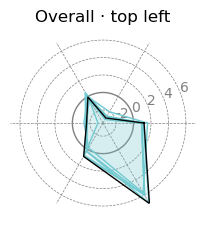

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_overall_top_left.pdf
1.726308462019997
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



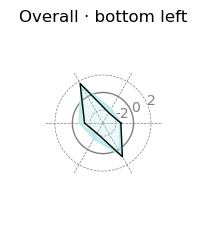

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_overall_bottom_left.pdf
1.7877574543615926
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



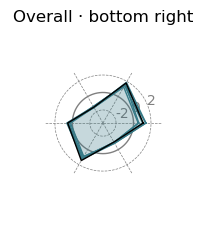

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_overall_bottom_right.pdf
1.1892926125758179
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



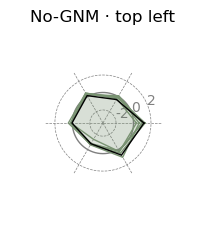

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_no_gnm_top_left.pdf
1.3290515450818234
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



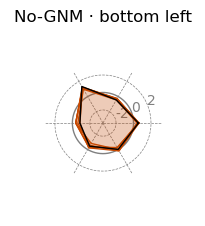

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_no_gnm_bottom_left.pdf
0.8620082780795716
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



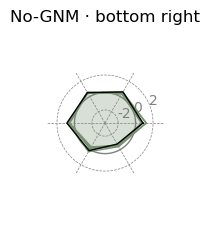

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_no_gnm_bottom_right.pdf
1.6658246653823063
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



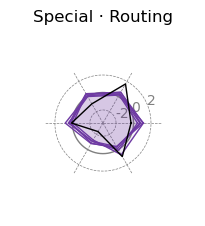

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_special_routing.pdf
0.9383620089592737
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



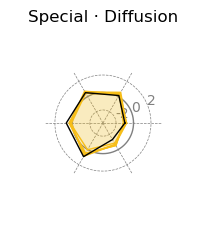

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_special_diffusion.pdf
1.2597162310907124
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



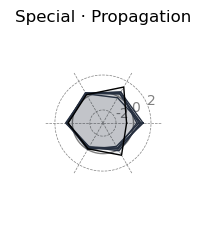

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_special_propagation.pdf
nan
-3.4991131080240865 7.1373730056234646


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/2569206637.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



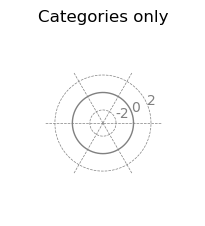

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_categories_only.pdf


In [76]:
# ── 2. Updated get_neighbours (unchanged logic, works with cat_scaled_all too) ─

def get_neighbours(orig_idx, embed, n=5, exclude_gnm=False, df_label=None, gnm_name=None):
    dists = pairwise_distances(embed[orig_idx:orig_idx + 1], embed)[0]
    dists[orig_idx] = np.inf
    if exclude_gnm and df_label is not None:
        dists[(df_label["dataset"] == gnm_name).values] = np.inf
    return np.argsort(dists)[:n].tolist()


# ── 3. Rebuild panels using category values ───────────────────────────────────

panels = []

for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = huge_df["color_dataset"].iloc[orig_idx] #### OR "black" OR COLOR_SCHEME[ds]
    nb_idx  = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [cat_scaled_all[i] for i in nb_idx]      # ← cat-level rows
    panels.append((
        f"Overall · {corner_name.replace('_', ' ')}",
        cat_scaled_all[orig_idx], 
        color,                # ← cat-level row
        f"spider_overall_{corner_name}.pdf",
        nb_vals,
    ))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    nb_idx  = get_neighbours(orig_idx, sel_pca_result, n=5,
                             exclude_gnm=True, df_label=sel_df_label, gnm_name=GNM_DATASET)
    nb_vals = [cat_scaled_all[i] for i in nb_idx]
    panels.append((
        f"No-GNM · {corner_name.replace('_', ' ')}",
        cat_scaled_all[orig_idx], color,
        f"spider_no_gnm_{corner_name}.pdf",
        nb_vals,
    ))

for ds_key, orig_idx in special_indices.items():
    label_text = LABEL_MAP[ds_key]
    color = COLOR_SCHEME[ds_key]
    nb_idx  = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [cat_scaled_all[i] for i in nb_idx]
    panels.append((
        f"Special · {label_text}",
        cat_scaled_all[orig_idx], color,
        f"spider_special_{label_text.lower()}.pdf",
        nb_vals,
    ))
    
    
# One empty one - no neighbors either, just to show the axes with category labels and no data. But make it have all rings visible to show the full scale of category values (unlike the others which may have some rings cut off if their max value is low)
panels.append((
    "Categories only",
    np.full(len(cat_labels), np.nan),
    COLOR,
    "spider_categories_only.pdf",
    None,
))

# ── 4. Render ─────────────────────────────────────────────────────────────────

all_vals = np.nanmax([v for _, vals, *_ in panels for v in vals])
dyn_ylim     = (cat_ylim[0], 2 if all_vals <= 2 else 4 if all_vals <= 4 else cat_ylim[1])
dyn_ring_vals = [r for r in RING_VALS if r <= dyn_ylim[1]]

for title, vals, color, fname, nb_vals in panels:
    make_spider_standalone(
        values          = vals,
        label           = title,
        color           = color,
        feature_labels  = cat_labels,        # ← category names
        title           = title,
        # ylim            = cat_ylim,
        ylim            = dyn_ylim,
        ring_vals       = dyn_ring_vals,
        filepath        = output_folder / fname,
        neighbour_vals_list = nb_vals,
        axis_colors     = COLOR, # cat_axis_colors,   # ← per-category label colors
    )


In [77]:
CATEGORY_COLOURS

{'Integration': '#4C72B0',
 'Segregation': '#DD8452',
 'Robustness': '#55A868',
 'Wiring': '#8172B2',
 'Dynamics': '#DA8BC3',
 'Computation': '#8C8C8C',
 'Structure': '#CCB974',
 'Communication': '#64B5CD',
 'Economic efficiency': '#E24A33'}

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/kaysons_generated_networks_routing_pca_loadings_coloured_by_category.pdf


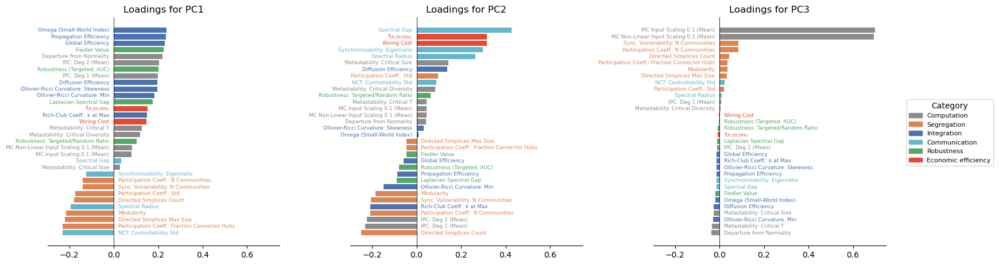

In [78]:
fig, axs = plt.subplots(nrows=1, ncols=3,
                        figsize=viz.cm_to_inch((40, 12)),
                        sharex=True)

for i in range(3):
    ordered_pc_i    = np.argsort(loadings[:, i])
    loadings_sorted = loadings[ordered_pc_i]
    names_sorted    = metric_names[ordered_pc_i]
    names_long      = [PROPERTY_NAMES[m] for m in names_sorted]

    bar_colours = []
    for m in names_sorted:
        cat = meta.loc[m, "Category"] if m in meta.index else None
        bar_colours.append(CATEGORY_COLOURS[cat]) # .get(cat, "#AAAAAA"))

    axs[i].barh(range(num_metrics), loadings_sorted[:, i], color=bar_colours)
    axs[i].axvline(0, color="black", linewidth=0.6)
    axs[i].set_title(f"Loadings for PC{i+1}")

    # Remove default y tick labels
    axs[i].set_yticks([])

    PAD = 0.02  # small gap from the zero line in data units
    for j, (val, name, colour) in enumerate(zip(loadings_sorted[:, i], names_long, bar_colours)):
        if val >= 0:
            # Bar goes right → label on the left of zero
            axs[i].text(-PAD, j, name,
                        ha="right", va="center", fontsize=6.5,
                        color=colour, # fontweight="bold"
                        )
        else:
            # Bar goes left → label on the right of zero
            axs[i].text(PAD, j, name,
                        ha="left", va="center", fontsize=6.5,
                        color=colour,
                        # fontweight="bold"
                        )
            
    # Remove spines and ticks for a cleaner look
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['left'].set_visible(False)

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=CATEGORY_COLOURS[cat], label=cat)
           for cat in meta["Category"].value_counts().index] # in meta.value_counts("Category").items #  CATEGORY_COLOURS.items()
        #    if cat in meta["Category"].values]
fig.legend(handles=handles, title="Category",
           bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=8)

plt.tight_layout()
plt.savefig(output_folder / f"{dataset_name}_pca_loadings_coloured_by_category.pdf", bbox_inches="tight")
print(output_folder / f"{dataset_name}_pca_loadings_coloured_by_category.pdf")
plt.show()

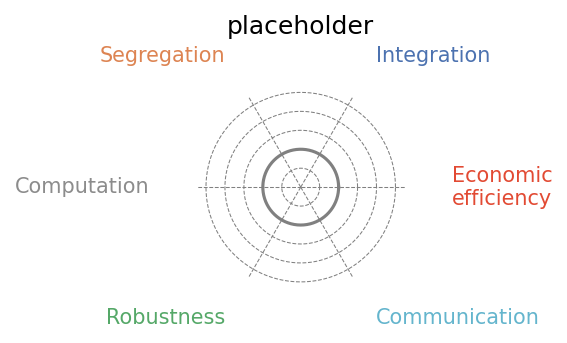

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_labels_only.pdf


In [ ]:

def make_legend_plot(feature_labels, angles, filepath, label_color=None):
    """Empty radar with only the spoke labels visible."""
    
    n = len(feature_labels)
    angles_plot = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((9,6)), subplot_kw=dict(polar=True), dpi=150)
    # fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), subplot_kw=dict(polar=True), dpi=150)
    ax.set_ylim(YLIM[0], YLIM[1]) # -3.5, 3.5)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    # Draw spoke lines
    for angle in angles_plot:
        ax.plot([angle, angle], YLIM, # [-3.5, 3.5],
                color=label_color, linewidth=0.5, # 1.8, # 2, # 0.5, 
                linestyle="--", zorder=0)
        
    # ── Group arcs just outside the outermost ring ──
    local_min, local_max = YLIM[0], YLIM[1]
    arc_r = local_max + (local_max - local_min) * 0.12
    draw_axis_group_arcs(ax, list(feature_labels), angles, arc_r, AXIS_GROUPS)
    # Expand ylim slightly so the arc isn't clipped
    ax.set_ylim(local_min, arc_r + (local_max - local_min) * 0.05)

    # Zero ring
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    ax.plot(theta_ring, np.zeros(300), color=label_color, # "gray", 
            # linewidth=1.8,
            zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color=label_color, linewidth=0.5, 
                linestyle="--", zorder=0)

    # ── Category axis labels, colored per category ────────────────────────────

    # Replace " " in labels with newlines for better spacing
    feature_labels_to_print = [lbl.replace(" ", "\n") for lbl in feature_labels]
    font_colors = [CATEGORY_COLOURS[cat] for cat in feature_labels]
    
    # Add spoke labels manually
    for i, (angle, lbl) in enumerate(zip(angles_plot, feature_labels_to_print)):
        x = np.degrees(angle)
        ax.set_thetagrids(np.degrees(angles_plot), 
                          feature_labels_to_print,
                        #   fontweight="bold",
                        #   fontsize=8
                          )
        for idx, txt in enumerate(ax.get_xticklabels()):
            if txt.get_text() == lbl:
                txt.set_color(font_colors[i])
                # shift it a bit to the right (away from the spoke line)
                txt.set_horizontalalignment("left")
                txt.set_verticalalignment("center")
                
                if idx in [2,3,4]: 
                    txt.set_horizontalalignment("right")
                # txt.set_fontweight("bold")
                break
        # for i, (label_text, angle) in enumerate(zip(feature_labels_to_print, angles)):
        #     lbl_color = font_colors[i] if font_colors is not None else "black"
        #     # Find the Text object matplotlib just created and recolor it
            

        # ax.set_title("Legend / Labels", pad=16) # , fontsize=10, pad=16, fontweight="bold")
    plt.title("placeholder") 
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(filepath)


make_legend_plot(cat_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf", label_color=COLOR)

In [80]:
loadings.shape

(32, 10)

In [81]:
# the labels from the loadings 
loading_labels = [feature_cols[i] for i in range(loadings.shape[0])]
loading_labels_cat = [meta.loc[feat, "Category"] if feat in meta.index else "Unknown" for feat in loading_labels]
loading_labels

['modularity',
 'omega',
 'directed_simplices_count',
 'directed_simplices_max_size',
 'global_efficiency',
 'diffusion_efficiency',
 'propagation_efficiency',
 'wiring_cost',
 'proportion_long_range_connections_0.3956',
 'rich_club_coefficient_rc_k_at_max',
 'spectral_radius',
 'spectral_gap',
 'synchronizability_eigenratio_eigenratio',
 'algebraic_connectivity_fiedler_value',
 'algebraic_connectivity_laplacian_spectral_gap',
 'departure_from_normality_schur',
 'repertoire_sweep_weighted_by_distances_T_critical',
 'repertoire_sweep_weighted_by_distances_size_critical',
 'repertoire_sweep_weighted_by_distances_diversity_critical',
 'participation_coefficient_n_communities',
 'participation_coefficient_pc_std',
 'participation_coefficient_pc_frac_connector',
 'ollivier_ricci_curvature_orc_min',
 'ollivier_ricci_curvature_orc_skewness',
 'targeted_attack_robustness_rob_targeted_auc',
 'targeted_attack_robustness_rob_ratio',
 'community_synchronization_vulnerability_n_communities',
 'nct_

In [82]:
loading_and_cat_df = pd.DataFrame({
    "feature": loading_labels,
    "category": loading_labels_cat,
    "PC1": loadings[:, 0],
    "PC2": loadings[:, 1],
})
# set feature as index
loading_and_cat_df.set_index("feature", inplace=True)
loading_and_cat_df

,category,PC1,PC2
feature,,,
modularity,Segregation,0.027821,0.142078
omega,Integration,0.033645,0.427910
directed_simplices_count,Segregation,0.078564,0.044994
directed_simplices_max_size,Segregation,0.082120,0.044942
global_efficiency,Integration,0.103252,0.062425
diffusion_efficiency,Integration,0.119038,0.083461
propagation_efficiency,Integration,-0.124930,0.296862
wiring_cost,Economic efficiency,0.125716,0.045085
proportion_long_range_connections_0.3956,Economic efficiency,-0.138823,-0.208593


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/huge_pca_optimizers_without_labels.pdf


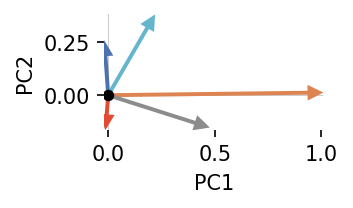

In [83]:
# ── Category-level aggregate vectors ─────────────────────────────────────────
# loadings: DataFrame (n_vars × 2), already scaled by √eigenvalue

cat_vectors = {}
for cat, colour in CATEGORY_COLOURS.items():
    # plt.figure(dpi=100, figsize=viz.cm_to_inch((2,2))) 

    # Variables in this category that also have loadings
    cat_vars = [c for c in loading_labels
                if c in meta.index and meta.loc[c, "Category"] == cat]
    if not cat_vars:
        continue

    cat_loads = loading_and_cat_df.loc[cat_vars]  # shape: (n_cat_vars, 2)

    # Weight each variable by its total loading magnitude (L2 norm across PC1+PC2)
    weights = np.sqrt(cat_loads["PC1"]**2 + cat_loads["PC2"]**2)
    # weights = weights / weights.sum()  # normalise to sum=1

    # # Print the values of cat_loads["PC1"] and cat_loads["PC2"] for debugging (check if <0..)
    # print(f"Category: {cat}")
    # print("PC1 loadings:")
    # print(cat_loads["PC1"])
    # print("PC2 loadings:")
    # print(cat_loads["PC2"])
    
    # Weighted sum → one (PC1, PC2) vector per category
    vx = cat_loads["PC1"].sum() # (cat_loads["PC1"] * weights).sum()
    vy = cat_loads["PC2"].sum() # (cat_loads["PC2"] * weights).sum()
    cat_vectors[cat] = (vx, vy)
    
    # plt.scatter(cat_loads["PC1"], cat_loads["PC2"], color=colour, s=20)
    # plt.title(f"{cat} variables in PCA space")
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    # plt.axhline(0, color="grey", lw=0.5, alpha=0.4)
    # plt.axvline(0, color="grey", lw=0.5, alpha=0.4)
    # plt.tight_layout()
    # plt.show()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
ax.scatter([0], [0], color="black", s=20, zorder=6)

for cat, (vx, vy) in cat_vectors.items():
    colour = CATEGORY_COLOURS[cat]
    ax.quiver(
        0, 0, vx, vy,
        angles="xy", scale_units="xy", scale=1,
        color=colour, width=0.018, #, # 0.012,
        headwidth=4, # 6, # 4, 
        headlength=4, # 6, # 5, 
        headaxislength=4, # 6, # 4,
        zorder=5,
    )
    # nudge = 1.15
    # ax.text(vx * nudge, vy * nudge, cat,
    #         fontsize=8, ha="center", va="center",
    #         color=colour, fontweight="bold")

# Symmetric axis limits
# max_val = max(np.sqrt(vx**2 + vy**2) for vx, vy in cat_vectors.values()) #  * 1.4
max_val_x = max([vx for vx, vy in cat_vectors.values()])
min_val_y = min([vy for vx, vy in cat_vectors.values()])
min_val_x = min([vx for vx, vy in cat_vectors.values()])
max_val_y = max([vy for vx, vy in cat_vectors.values()])
# ax.set_xlim(-max_val, max_val)
# ax.set_ylim(-max_val, max_val)
ax.set_xlim(min_val_x, max_val_x)
ax.set_ylim(min_val_y, max_val_y)
# ax.set_xticks([-0.25, 0, 0.25])
# ax.set_yticks([-0.25, 0, 0.25])
ax.set_aspect("equal")
ax.set_xlabel("PC1") # , fontsize=9)
ax.set_ylabel("PC2") # , fontsize=9)
# ax.set_title("Category vectors in PCA space\n(weighted by loading magnitude)", fontsize=9)

# Remove frame, keep ticks
for spine in ax.spines.values():
    spine.set_visible(False)
# ax.tick_params(labelsize=7)

plt.tight_layout()

plt.savefig(output_folder / f"huge_pca_optimizers_without_labels.pdf") # , dpi=300)
print(output_folder / f"huge_pca_optimizers_without_labels.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/huge_pca_optimizers_labels.pdf


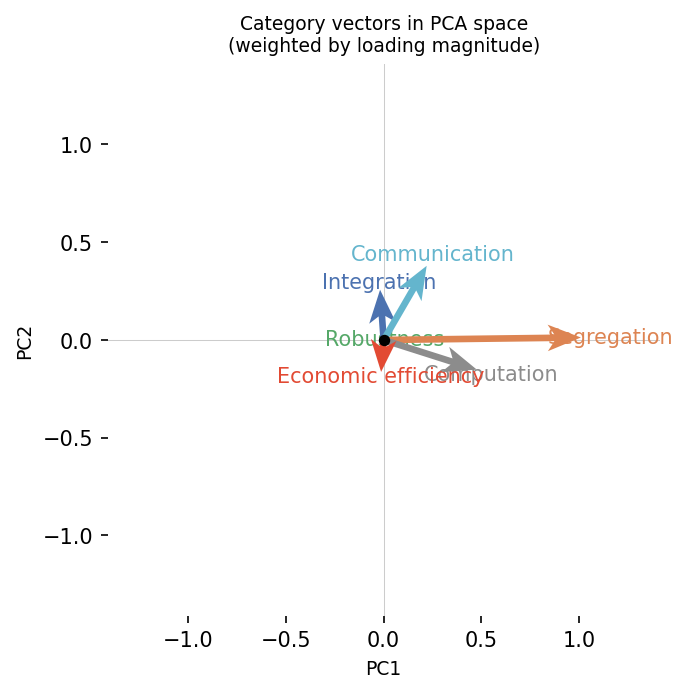

In [84]:
# ── Category-level aggregate vectors ─────────────────────────────────────────
# loadings: DataFrame (n_vars × 2), already scaled by √eigenvalue

cat_vectors = {}
for cat, colour in CATEGORY_COLOURS.items():
    # plt.figure(dpi=100, figsize=viz.cm_to_inch((2,2))) 

    # Variables in this category that also have loadings
    cat_vars = [c for c in loading_labels
                if c in meta.index and meta.loc[c, "Category"] == cat]
    if not cat_vars:
        continue

    cat_loads = loading_and_cat_df.loc[cat_vars]  # shape: (n_cat_vars, 2)

    # Weight each variable by its total loading magnitude (L2 norm across PC1+PC2)
    weights = np.sqrt(cat_loads["PC1"]**2 + cat_loads["PC2"]**2)
    # weights = weights / weights.sum()  # normalise to sum=1

    # # Print the values of cat_loads["PC1"] and cat_loads["PC2"] for debugging (check if <0..)
    # print(f"Category: {cat}")
    # print("PC1 loadings:")
    # print(cat_loads["PC1"])
    # print("PC2 loadings:")
    # print(cat_loads["PC2"])
    
    # Weighted sum → one (PC1, PC2) vector per category
    vx = cat_loads["PC1"].sum() # (cat_loads["PC1"] * weights).sum()
    vy = cat_loads["PC2"].sum() # (cat_loads["PC2"] * weights).sum()
    cat_vectors[cat] = (vx, vy)
    
    # plt.scatter(cat_loads["PC1"], cat_loads["PC2"], color=colour, s=20)
    # plt.title(f"{cat} variables in PCA space")
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    # plt.axhline(0, color="grey", lw=0.5, alpha=0.4)
    # plt.axvline(0, color="grey", lw=0.5, alpha=0.4)
    # plt.tight_layout()
    # plt.show()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), dpi=150)

ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
ax.scatter([0], [0], color="black", s=20, zorder=6)

for cat, (vx, vy) in cat_vectors.items():
    colour = CATEGORY_COLOURS[cat]
    ax.quiver(
        0, 0, vx, vy,
        angles="xy", scale_units="xy", scale=1,
        color=colour, width=0.012,
        headwidth=4, headlength=5, headaxislength=4,
        zorder=5,
    )
    nudge = 1.15
    ax.text(vx * nudge, vy * nudge, cat,
            # fontsize=8, 
            ha="center", va="center",
            color=colour, # fontweight="bold"
            )

# Symmetric axis limits
max_val = max(np.sqrt(vx**2 + vy**2) for vx, vy in cat_vectors.values()) * 1.4
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.set_aspect("equal")
ax.set_xlabel("PC1", fontsize=9)
ax.set_ylabel("PC2", fontsize=9)
ax.set_title("Category vectors in PCA space\n(weighted by loading magnitude)", fontsize=9)

# Remove frame, keep ticks
for spine in ax.spines.values():
    spine.set_visible(False)
# ax.tick_params(labelsize=7)

plt.tight_layout()

plt.savefig(output_folder / f"huge_pca_optimizers_labels.pdf") # , dpi=300)
print(output_folder / f"huge_pca_optimizers_labels.pdf")
plt.show()

# Taxonomies 

In [85]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
taxonomy = "order" # phylogenetic_group" # "order" 

GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]
# info_mami = info_mami[info_mami[taxonomy].isin(GROUPS_TO_INCLUDE)]

# info_mami["tax_color"] = info_mami[taxonomy].astype("category").cat.codes

df_mami = pd.concat([sel_df_label[sel_df_label["dataset"] == "suarez_MaMI_dataset"].reset_index(), info_mami], axis=1) # , left_index=True, right_on=True) # "animal_name")

names = df_mami[taxonomy].unique() # ["tax_color"]
color_map = plt.cm.get_cmap("tab10_r", len(names)) # "RdYlGn_r", len(names))
color_dict = {name: color_map(i) for i, name in enumerate(names)}

color_dict["Primates"] = "#AD5C4D"
color_dict["Rodentia"] = "#AD8B4E"
color_dict["Carnivora"] = "#4D9EAD"
color_dict["Cetartiodactyla"] = "#4C6FAD"

df_mami["tax_color"] = df_mami[taxonomy].map(color_dict)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_16727/3861314724.py:26: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [86]:
for key, o in info_mami["order"].value_counts().items():
    print(key, ":", o)

Carnivora : 51
Primates : 46
Cetartiodactyla : 40
Rodentia : 29
Chiroptera : 29
Marsupialia : 9
Perissodactyla : 7
Lagomorpha : 5
Eulipotyphla : 4
Hyracoidea : 2
Scandentia : 1
Xenarthra : 1


In [87]:
from sklearn.metrics import pairwise_distances
from scipy.stats import f_oneway
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ── Extract the relevant PCA coordinates + labels ─────────────────────────────

mami_mask  = (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
tax_mask   = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE).values
combined   = mami_mask.copy()
combined[mami_mask] = tax_mask          # both conditions

X      = sel_pca_result[combined, :2]   # PC1 + PC2 only
labels = df_mami[tax_mask][taxonomy].values

# ── Test 1: PERMANOVA (permutation-based MANOVA on distances) ─────────────────
# "Are the groups more separated than random chance?"

from sklearn.utils import shuffle

def permanova(X, labels, n_permutations=999):
    def f_stat(X, labels):
        groups  = [X[labels == g] for g in np.unique(labels)]
        grand_m = X.mean(axis=0)
        ss_between = sum(len(g) * ((g.mean(0) - grand_m)**2).sum() for g in groups)
        ss_within  = sum(((g - g.mean(0))**2).sum() for g in groups)
        k, n = len(groups), len(X)
        return (ss_between / (k-1)) / (ss_within / (n-k))

    observed = f_stat(X, labels)
    null_dist = [f_stat(X, shuffle(labels)) for _ in range(n_permutations)]
    p = (np.sum(np.array(null_dist) >= observed) + 1) / (n_permutations + 1)
    return observed, p

f_obs, p_perm = permanova(X, labels)
print(f"PERMANOVA  →  F = {f_obs:.3f},  p = {p_perm:.4f}")

# ── Test 2: Per-axis ANOVA ─────────────────────────────────────────────────────
# "Does any single PC axis separate the groups?"

groups_pc1 = [X[labels == g, 0] for g in np.unique(labels)]
groups_pc2 = [X[labels == g, 1] for g in np.unique(labels)]
f1, p1 = f_oneway(*groups_pc1)
f2, p2 = f_oneway(*groups_pc2)
print(f"ANOVA PC1  →  F = {f1:.3f},  p = {p1:.4f}")
print(f"ANOVA PC2  →  F = {f2:.3f},  p = {p2:.4f}")

# ── Test 3: LDA cross-validated accuracy ──────────────────────────────────────
# "Can we predict group membership better than chance?"

from sklearn.model_selection import cross_val_score
lda      = LinearDiscriminantAnalysis()
cv_score = cross_val_score(lda, X, labels, cv=5, scoring="accuracy").mean()
chance   = 1 / len(np.unique(labels))
print(f"LDA 5-fold CV accuracy = {cv_score:.3f}  (chance = {chance:.3f})")

PERMANOVA  →  F = 7.300,  p = 0.0010
ANOVA PC1  →  F = 1.144,  p = 0.3371
ANOVA PC2  →  F = 13.289,  p = 0.0000
LDA 5-fold CV accuracy = 0.297  (chance = 0.200)


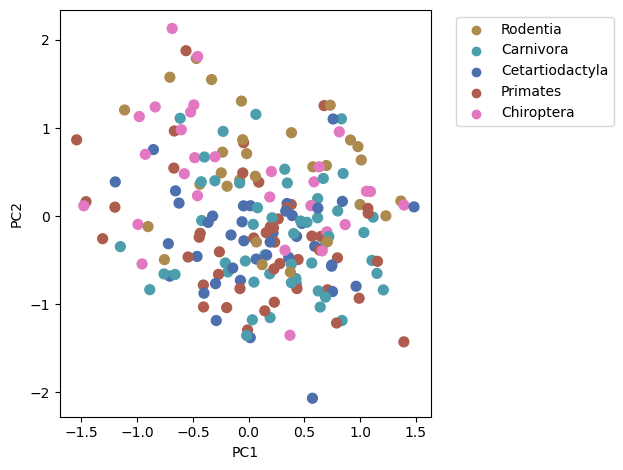

In [88]:
sel_pca_result_four_animal_orders = sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset"][tax_mask]

plt.scatter(sel_pca_result_four_animal_orders[:, 0], 
            sel_pca_result_four_animal_orders[:, 1], 
            c=df_mami[tax_mask]["tax_color"], 
            s=50)

# Faking the legend
for name in df_mami[taxonomy][tax_mask].unique(): # GROUPS_TO_INCLUDE: # color_dict:
    plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                color=color_dict[name],
                    label=str(name))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=3, frameon=False, labelspacing=1, title='City Area') phylogenetic_group

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

In [89]:
square_x_lim = (-3, 2)
square_y_lim = (-3, 2)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/legend_tax_groups.pdf


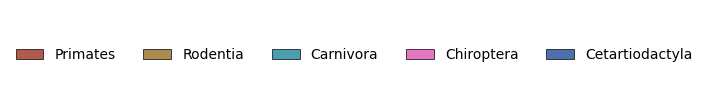

In [90]:

import matplotlib.patches as mpatches

handles = []
for g in GROUPS_TO_INCLUDE:
    handles.append(
        mpatches.Patch(facecolor=color_dict[g],
               label=g,
               edgecolor="black", 
               linewidth=0.5)
    )

fig, ax = plt.subplots(figsize=viz.cm_to_inch((18, 3)))

legend = ax.legend(handles=handles, ncol=6, loc="center", frameon=False) #, handler_map={gnm_patch: HandlerGradient(pixels)}, handlelength=1, handleheight=1)
ax.axis("off")

fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(output_folder / "legend_tax_groups.pdf",
            bbox_inches=bbox, dpi=300)
print(output_folder / "legend_tax_groups.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_for_tax_orders_labelled.pdf


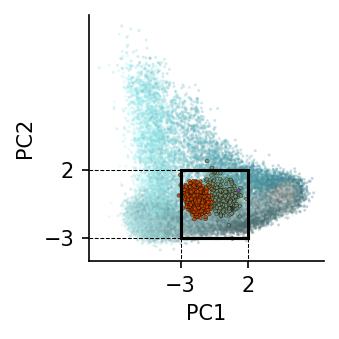

In [91]:
# for thing_to_be_colored in measures_of_interest:

fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

# KDE for the whole MaMI (in the background of each plot)
sns.kdeplot(x=sel_pca_result_four_animal_orders[:, 0], 
            y=sel_pca_result_four_animal_orders[:, 1], 
            color=COLOR_SCHEME["suarez_MaMI_dataset"], # "lightgray",
            # linewidth=1, # 1.5, # 0.5,
            ax=ax, fill=True, # False, # True, 
            alpha=1, # 0.5, 
            # zorder=3
            )

# KDE for the whole human dataset (in the background of each plot)
human_mask = (sel_df_label["dataset"] == "lexis_data_developing").values
sns.kdeplot(x=sel_pca_result[human_mask][:, 0], 
            y=sel_pca_result[human_mask][:, 1], 
            color=COLOR_SCHEME["lexis_data_developing"], # "lightblue", 
            ax=ax, fill=True, # False, # True, 
            alpha=1, # 0.5, 
            # zorder=3
            )

for ds in sel_df_label["dataset"].unique():
    # if "gnm" in ds.lower():
        mask = (sel_df_label["dataset"] == ds).values
        ax.scatter(
            sel_pca_result[mask, 0], sel_pca_result[mask, 1],
            # c=COLOR_SCHEME[ds], 
            # c=huge_df[mask]["color_dataset"], # COLOR_SCHEME[ds], 
            c=huge_df[mask]["color_dataset"], # get_combined_colors(huge_dfsel_df_label[mask][thing_to_be_colored], # color by the chosen metric instead of dataset
            # cmap=cmap,
            label=LABEL_MAP.get(ds, ds),
            alpha=0.3 if ds == GNM_DATASET else 0.8, 
            s=2 if ds == GNM_DATASET else 3, 
            edgecolors="none" if ds == GNM_DATASET else "black", 
            linewidths=0 if ds == GNM_DATASET else 0.2,
            zorder=1,
        )
        
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
ax.set_xticks([-3, 2]) # Hide x-axis ticks for cleaner look
ax.set_yticks([-3, 2]) # Hide y-axis ticks for cleaner look
# plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), 
#              ax=ax, 
#              label=PROPERTY_NAMES[thing_to_be_colored])
# ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

# draw rectangle around GNM square_x_lim and square_y_lim
rect = plt.Rectangle((square_x_lim[0], square_y_lim[0]), 
                     square_x_lim[1] - square_x_lim[0], 
                     square_y_lim[1] - square_y_lim[0], 
                     linewidth=1.5, edgecolor="black", facecolor="none", zorder=2)
ax.add_patch(rect)

# get minimum x and y values from the axes
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# add lines from the edges of the rectangle to the axes
buffer = 0 # 0.5
linestyle = "--"
ax.plot([square_x_lim[0]-buffer, x_min], [square_y_lim[0], square_y_lim[0]], color="black", linestyle=linestyle, linewidth=0.5, zorder=2)
ax.plot([square_x_lim[0]-buffer, x_min], [square_y_lim[1], square_y_lim[1]], color="black", linestyle=linestyle, linewidth=0.5, zorder=2)
ax.plot([square_x_lim[0], square_x_lim[0]], [square_y_lim[0], y_min], color="black", linestyle=linestyle, linewidth=0.5, zorder=2)
ax.plot([square_x_lim[1], square_x_lim[1]], [square_y_lim[0], y_min], color="black", linestyle=linestyle, linewidth=0.5, zorder=2)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig(output_folder / f"pca_for_tax_orders_labelled.pdf", dpi=150, bbox_inches="tight")
print(output_folder / f"pca_for_tax_orders_labelled.pdf")
# plt.show()


Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_kde_orders_permanova_pca.pdf


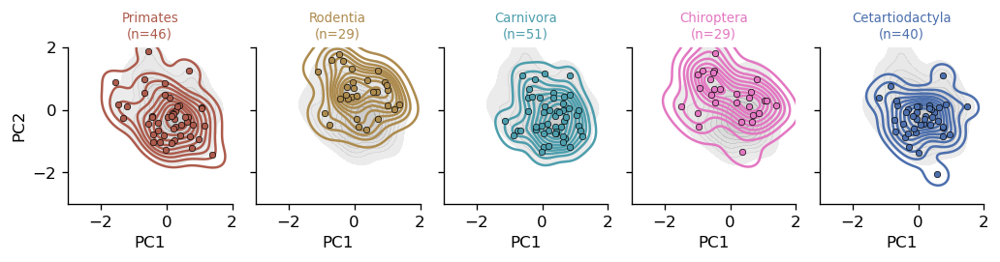

\begin{table}[ht]
\centering
\begin{tabular}{llccc}
\hline
\textbf{Order A} & \textbf{Order B} & $F$ & $p$ & Cohen's $d$ \\
\hline
Primates & Rodentia & 11.73 & \textbf{0.001 **} & 0.12 \\
Primates & Carnivora & 0.93 & 0.391 ns & 0.29 \\
Primates & Chiroptera & 8.63 & \textbf{0.001 **} & 0.17 \\
Primates & Cetartiodactyla & 0.06 & 0.934 ns & 0.02 \\
Rodentia & Carnivora & 14.28 & \textbf{0.001 **} & 0.16 \\
Rodentia & Chiroptera & 0.70 & 0.492 ns & 0.29 \\
Rodentia & Cetartiodactyla & 15.27 & \textbf{0.001 **} & 0.11 \\
Carnivora & Chiroptera & 11.93 & \textbf{0.002 **} & 0.45 \\
Carnivora & Cetartiodactyla & 0.98 & 0.355 ns & 0.30 \\
Chiroptera & Cetartiodactyla & 11.08 & \textbf{0.001 **} & 0.20 \\
\hline
\end{tabular}
\caption{Pairwise PERMANOVA (999 permutations) on the first two principal components. $F$: pseudo-$F$ statistic. $p$: permutation $p$-value. Cohen's $d$ computed on PC1. Significance: *** $p<0.001$, ** $p<0.01$, * $p<0.05$, ns $p\geq0.05$.}
\label{tab:permanova_orders}

In [92]:
from utils_permanova import run_permanova, sig_stars, print_latex_permanova_table
from itertools import combinations

# ── Config ────────────────────────────────────────────────────────────────────

square_x_lim = (-3, 2)
square_y_lim = (-3, 2)

# ── Data (already exists from your code) ─────────────────────────────────────
X_all  = sel_pca_result_four_animal_orders[:, :2]   # (n_subjects, 2)
labels = df_mami[tax_mask]["order"].values           # aligned with X_all


results = {}
for a, b in combinations(GROUPS_TO_INCLUDE, 2):
    m      = np.isin(labels, [a, b])
    X_, y_ = X_all[m], labels[m]
    if len(np.unique(y_)) < 2:
        continue
    F, p   = run_permanova(X_, y_)
    xa, xb = X_[y_ == a, 0], X_[y_ == b, 0]
    d      = abs(xa.mean() - xb.mean()) / np.sqrt((xa.var() + xb.var()) / 2 + 1e-9)
    results[(a, b)] = dict(F=F, p=p, d=d)
    # print(f"{a[:4]} vs {b[:4]}: F={F:.2f}  p={p:.4f}  d={d:.2f}")


# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 5,
    figsize=viz.cm_to_inch((22, 6)),
    gridspec_kw={"width_ratios": [1, 1, 1, 1, 1]},
    dpi=120, 
    sharex=True, sharey=True
)

# ── 4 KDE panels ──────────────────────────────────────────────────────────────
for ax, focal in zip(axes[:5], GROUPS_TO_INCLUDE):
    mask_focal  = labels == focal
    color_focal = color_dict[focal]

    # Background KDE — all four orders
    sns.kdeplot(x=X_all[:, 0], y=X_all[:, 1], ax=ax,
                fill=True, color="lightgray", alpha=0.3, zorder=1)

    # Focal KDE contour
    if mask_focal.sum() > 3:
        sns.kdeplot(x=X_all[mask_focal, 0], y=X_all[mask_focal, 1],
                    ax=ax, fill=False, color=color_focal, alpha=1, zorder=4)

    # Focal scatter
    ax.scatter(X_all[mask_focal, 0], X_all[mask_focal, 1],
               color=color_focal, s=15, edgecolors="black",
               linewidths=0.4, zorder=5)

    ax.set_xlim(*square_x_lim)
    ax.set_ylim(*square_y_lim)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2" if ax is axes[0] else "")
    ax.set_title(f"{focal}\n(n={mask_focal.sum()})", fontsize=8,
                 color=color_focal)
    ax.spines[["top", "right"]].set_visible(False)


# plt.suptitle("PCA space - phylogenetic order separation", fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(output_folder / "pca_kde_orders_permanova_pca.pdf", bbox_inches="tight")
print(output_folder / "pca_kde_orders_permanova_pca.pdf")
plt.show()


    
print_latex_permanova_table(results, GROUPS_TO_INCLUDE, sig_stars)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_selected_properties_MaMI.pdf


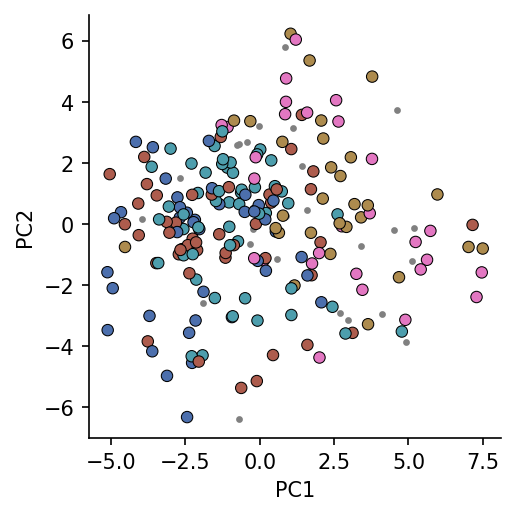

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_selected_properties_MaMI_scree_plot.pdf


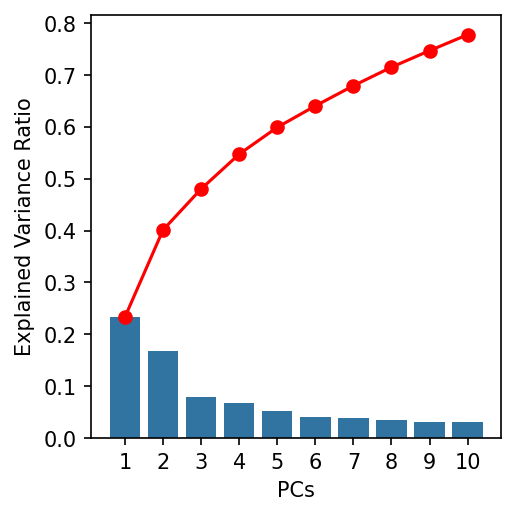

In [93]:
# PCA only on MaMI 
huge_df_mami = huge_df[huge_df["dataset"] == "suarez_MaMI_dataset"].copy()
huge_df_properties_mami = huge_df_properties[huge_df["dataset"] == "suarez_MaMI_dataset"].copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties_mami)  # .drop(columns=["dataset", "color_dataset"]))

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(scaled_data)

# Get loadings 
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
                        index=huge_df_properties_mami.columns)

plt.figure(figsize=viz.cm_to_inch((9,9)), dpi=150)
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=5, 
            alpha=1, # 0.4, 
            c="gray", # df_mami["tax_color"], 
        #     label=df_mami["order"] 
            # label=huge_df['dataset']
        )

plt.scatter(x=pca_result[tax_mask][:,0], 
            y=pca_result[tax_mask][:,1], 
            s=30, 
            alpha=1, # 0.4, 
            c=df_mami[tax_mask]["tax_color"], # dict_with_all_datasets["suarez_MaMI_dataset"][tax_mask]["color_dataset"], # df_mami["tax_color"],
            edgecolors="black", linewidths=0.5, zorder=2
            # df_mami[tax_mask]["order"] 
            # label=huge_df['dataset']
        )

# for ax, animal in zip(axes.flatten(), df_mami[tax_mask]["order"].unique()): 

# Fake the legend 
for name in df_mami[tax_mask]["order"].unique(): # GROUPS_TO_INCLUDE: # color_dict:
    plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                color=color_dict[name],
                    label=str(name))
    
# Remove the upper and the right spines
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)

# plt.title("PCA of Metrics")
plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.legend()
plt.tight_layout()

plt.savefig(output_folder / "pca_selected_properties_MaMI.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "pca_selected_properties_MaMI.pdf")
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=viz.cm_to_inch((9,9)), dpi=150)
# sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
sns.barplot(x=[f"{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
# plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("PCs")
plt.tight_layout()
plt.savefig(output_folder / "pca_selected_properties_MaMI_scree_plot.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "pca_selected_properties_MaMI_scree_plot.pdf")
plt.show()

In [94]:
# the labels from the loadings 
loading_labels = [feature_cols[i] for i in range(loadings.shape[0])]
loading_labels_cat = [meta.loc[feat, "Category"] if feat in meta.index else "Unknown" for feat in loading_labels]
loading_labels


['modularity',
 'omega',
 'directed_simplices_count',
 'directed_simplices_max_size',
 'global_efficiency',
 'diffusion_efficiency',
 'propagation_efficiency',
 'wiring_cost',
 'proportion_long_range_connections_0.3956',
 'rich_club_coefficient_rc_k_at_max',
 'spectral_radius',
 'spectral_gap',
 'synchronizability_eigenratio_eigenratio',
 'algebraic_connectivity_fiedler_value',
 'algebraic_connectivity_laplacian_spectral_gap',
 'departure_from_normality_schur',
 'repertoire_sweep_weighted_by_distances_T_critical',
 'repertoire_sweep_weighted_by_distances_size_critical',
 'repertoire_sweep_weighted_by_distances_diversity_critical',
 'participation_coefficient_n_communities',
 'participation_coefficient_pc_std',
 'participation_coefficient_pc_frac_connector',
 'ollivier_ricci_curvature_orc_min',
 'ollivier_ricci_curvature_orc_skewness',
 'targeted_attack_robustness_rob_targeted_auc',
 'targeted_attack_robustness_rob_ratio',
 'community_synchronization_vulnerability_n_communities',
 'nct_

In [95]:
loading_and_cat_df = pd.DataFrame({
        "feature": loading_labels,
        "category": loading_labels_cat,
        "PC1": loadings["PC1"].values, # loadings[:, 0],
        "PC2": loadings["PC2"].values, # loadings[:, 1],
        # "PC3": loadings["PC3"].values, # loadings[:, 2],
    })
# set feature as index
loading_and_cat_df.set_index("feature", inplace=True)
loading_and_cat_df

,category,PC1,PC2
feature,,,
modularity,Segregation,-0.276445,-0.206752
omega,Integration,0.177641,0.337742
directed_simplices_count,Segregation,-0.174725,-0.258548
directed_simplices_max_size,Segregation,0.011829,-0.240713
global_efficiency,Integration,0.222554,0.218996
diffusion_efficiency,Integration,0.289027,0.179007
propagation_efficiency,Integration,-0.206974,0.235061
wiring_cost,Economic efficiency,-0.026492,-0.026576
proportion_long_range_connections_0.3956,Economic efficiency,0.059366,-0.004346


In [96]:
GROUPS_TO_INCLUDE

['Primates', 'Rodentia', 'Carnivora', 'Chiroptera', 'Cetartiodactyla']

Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
Dist is symetric: True
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_kde_orders_permanova_mami_pca.pdf


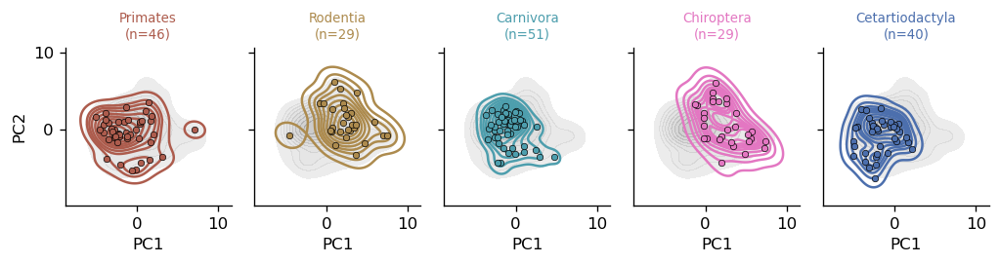

\begin{table}[ht]
\centering
\begin{tabular}{llccc}
\hline
\textbf{Order A} & \textbf{Order B} & $F$ & $p$ & Cohen's $d$ \\
\hline
Primates & Rodentia & 25.56 & \textbf{0.001 **} & 1.51 \\
Primates & Carnivora & 1.03 & 0.361 ns & 0.16 \\
Primates & Chiroptera & 23.40 & \textbf{0.001 **} & 1.54 \\
Primates & Cetartiodactyla & 1.64 & 0.196 ns & 0.35 \\
Rodentia & Carnivora & 25.22 & \textbf{0.001 **} & 1.58 \\
Rodentia & Chiroptera & 0.20 & 0.827 ns & 0.06 \\
Rodentia & Cetartiodactyla & 39.46 & \textbf{0.001 **} & 2.03 \\
Carnivora & Chiroptera & 23.36 & \textbf{0.001 **} & 1.61 \\
Carnivora & Cetartiodactyla & 5.76 & \textbf{0.003 **} & 0.61 \\
Chiroptera & Cetartiodactyla & 35.37 & \textbf{0.001 **} & 2.05 \\
\hline
\end{tabular}
\caption{Pairwise PERMANOVA (999 permutations) on the first two principal components. $F$: pseudo-$F$ statistic. $p$: permutation $p$-value. Cohen's $d$ computed on PC1. Significance: *** $p<0.001$, ** $p<0.01$, * $p<0.05$, ns $p\geq0.05$.}
\label{tab:permano

In [97]:
from utils_permanova import run_permanova, sig_stars, print_latex_permanova_table
from itertools import combinations

# ── Config ────────────────────────────────────────────────────────────────────

# square_x_lim = (-3, 2)
# square_y_lim = (-3, 2)

# ── Data (already exists from your code) ─────────────────────────────────────
X_all  = pca_result[tax_mask][:, :2]   # (n_subjects, 2)
labels = df_mami[tax_mask]["order"].values # huge_df_mami[tax_mask]["order"].values           # aligned with X_all


results = {}
for a, b in combinations(GROUPS_TO_INCLUDE, 2):
    m      = np.isin(labels, [a, b])
    X_, y_ = X_all[m], labels[m]
    if len(np.unique(y_)) < 2:
        continue
    F, p   = run_permanova(X_, y_)
    xa, xb = X_[y_ == a, 0], X_[y_ == b, 0]
    d      = abs(xa.mean() - xb.mean()) / np.sqrt((xa.var() + xb.var()) / 2 + 1e-9)
    results[(a, b)] = dict(F=F, p=p, d=d)
    # print(f"{a[:4]} vs {b[:4]}: F={F:.2f}  p={p:.4f}  d={d:.2f}")


# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 5,
    figsize=viz.cm_to_inch((22, 6)),
    gridspec_kw={"width_ratios": [1, 1, 1, 1, 1]},
    dpi=120, 
    sharex=True, sharey=True
)

# ── 4 KDE panels ──────────────────────────────────────────────────────────────
for ax, focal in zip(axes[:5], GROUPS_TO_INCLUDE):
    mask_focal  = labels == focal
    color_focal = color_dict[focal]

    # Background KDE — all four orders
    sns.kdeplot(x=X_all[:, 0], y=X_all[:, 1], ax=ax,
                fill=True, color="lightgray", alpha=0.3, zorder=1)

    # Focal KDE contour
    if mask_focal.sum() > 3:
        sns.kdeplot(x=X_all[mask_focal, 0], y=X_all[mask_focal, 1],
                    ax=ax, fill=False, color=color_focal, alpha=1, zorder=4)

    # Focal scatter
    ax.scatter(X_all[mask_focal, 0], X_all[mask_focal, 1],
               color=color_focal, s=15, edgecolors="black",
               linewidths=0.4, zorder=5)

    # ax.set_xlim(*square_x_lim)
    # ax.set_ylim(*square_y_lim)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2" if ax is axes[0] else "")
    ax.set_title(f"{focal}\n(n={mask_focal.sum()})", fontsize=8,
                 color=color_focal)
    ax.spines[["top", "right"]].set_visible(False)


# plt.suptitle("PCA space - phylogenetic order separation", fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(output_folder / "pca_kde_orders_permanova_mami_pca.pdf", bbox_inches="tight")
print(output_folder / "pca_kde_orders_permanova_mami_pca.pdf")
plt.show()

    
print_latex_permanova_table(results, GROUPS_TO_INCLUDE, sig_stars)

In [98]:
[c for c in loading_labels
                if c in meta.index and meta.loc[c, "Category"] == cat]

['wiring_cost', 'proportion_long_range_connections_0.3956']

In [99]:
cat_loads = loading_and_cat_df.loc[cat_vars]
cat_loads

,category,PC1,PC2
feature,,,
wiring_cost,Economic efficiency,-0.026492,-0.026576
proportion_long_range_connections_0.3956,Economic efficiency,0.059366,-0.004346


TypeError: matplotlib.axes._axes.Axes.text() got multiple values for keyword argument 'ha'

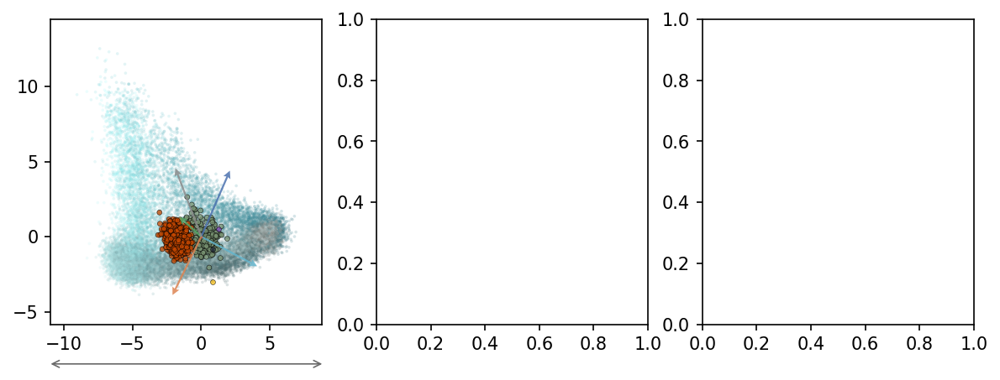

In [100]:
# ── Trade-off PCA: 3 panels with category quivers + pole annotations ──────────

# Extend cat_vectors to 3D if not already (reuse your loading_and_cat_df)
cat_vectors_3d = {}
for cat, colour in CATEGORY_COLOURS.items():
    cat_vars = [c for c in loading_labels if c in meta.index and meta.loc[c, "Category"] == cat]
    if not cat_vars:
        continue
    cat_loads = loading_and_cat_df.loc[cat_vars]
    cat_vectors_3d[cat] = np.array([
        cat_loads["PC1"].sum(),
        cat_loads["PC2"].sum(),
        cat_loads.get("PC3", pd.Series(np.zeros(len(cat_vars)))).sum()
            if "PC3" in cat_loads.columns else 0.0,
    ])

TRADEOFF_LABELS = {
    0: ("Wiring Economy",         "Global Integration"),
    1: ("Distributed Control",    "Global Coherence"),
    2: ("Broadcast Efficiency",   "Computational Richness"),
}

AXIS_PAIRS = [(0, 1), (0, 2), (1, 2)]

fig, axs = plt.subplots(1, 3,
                        figsize=viz.cm_to_inch((24, 8)),
                        dpi=150)

for ax, (xi, yi) in zip(axs, AXIS_PAIRS):

    # ── Scatter ───────────────────────────────────────────────────────────────
    for ds in sel_df_label["dataset"].unique():
        mask   = (sel_df_label["dataset"] == ds).values
        is_gnm = (ds == GNM_DATASET)
        ax.scatter(
            sel_pca_result[mask, xi],
            sel_pca_result[mask, yi],
            c          = huge_df[mask]["color_dataset"],
            label      = LABEL_MAP.get(ds, ds),
            alpha      = 0.20 if is_gnm else 0.75,
            s          = 3    if is_gnm else 8,
            edgecolors = "none"  if is_gnm else "black",
            linewidths = 0       if is_gnm else 0.3,
            zorder     = 1,
        )

    # ── Category quiver biplot ────────────────────────────────────────────────
    # Scale arrows so the longest one spans ~30% of the data range
    raw_vecs  = np.array([[v[xi], v[yi]] for v in cat_vectors_3d.values()])
    max_load  = np.sqrt((raw_vecs**2).sum(axis=1)).max()
    data_rng  = max(np.ptp(sel_pca_result[:, xi]),
                    np.ptp(sel_pca_result[:, yi]))
    scale     = 0.30 * data_rng / (max_load + 1e-9)

    for cat, vec in cat_vectors_3d.items():
        vx, vy = vec[xi] * scale, vec[yi] * scale
        ax.quiver(
            0, 0, vx, vy,
            angles="xy", scale_units="xy", scale=1,
            color      = CATEGORY_COLOURS[cat],
            alpha      = 0.85,
            width      = 0.007,
            headwidth  = 4,
            headlength = 4,
            headaxislength = 3.5,
            zorder     = 6,
        )

    # ── Axis limits with breathing room ──────────────────────────────────────
    pad_x = 0.12 * np.ptp(sel_pca_result[:, xi])
    pad_y = 0.12 * np.ptp(sel_pca_result[:, yi])
    xlim  = (sel_pca_result[:, xi].min() - pad_x,
             sel_pca_result[:, xi].max() + pad_x)
    ylim  = (sel_pca_result[:, yi].min() - pad_y,
             sel_pca_result[:, yi].max() + pad_y)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # ── Trade-off pole annotations ────────────────────────────────────────────
    lbl_kw   = dict(fontsize=6.5, color="dimgray", fontstyle="italic",
                    ha="center", va="top")
    arrow_kw = dict(arrowprops=dict(arrowstyle="<->", color="dimgray",
                                    lw=0.8, shrinkA=0, shrinkB=0),
                    xycoords="data", textcoords="data",
                    annotation_clip=False)

    x_neg, x_pos = TRADEOFF_LABELS[xi]
    y_neg, y_pos = TRADEOFF_LABELS[yi]

    y_ann = ylim[0] - 0.13 * np.ptp(ylim)
    # horizontal double-headed arrow + labels
    ax.annotate("", xy=(xlim[1], y_ann), xytext=(xlim[0], y_ann), **arrow_kw)
    ax.text(xlim[0], y_ann - 0.03 * np.ptp(ylim), f"← {x_neg}", **lbl_kw, ha="left")
    ax.text(xlim[1], y_ann - 0.03 * np.ptp(ylim), f"{x_pos} →",  **lbl_kw, ha="right")

    x_ann = xlim[0] - 0.14 * np.ptp(xlim)
    # vertical double-headed arrow + labels (rotated)
    ax.annotate("", xy=(x_ann, ylim[1]), xytext=(x_ann, ylim[0]), **arrow_kw)
    ax.text(x_ann - 0.01 * np.ptp(xlim), ylim[0],
            f"↓ {y_neg}", fontsize=6.5, color="dimgray", fontstyle="italic",
            ha="right", va="bottom", rotation=90)
    ax.text(x_ann - 0.01 * np.ptp(xlim), ylim[1],
            f"↑ {y_pos}", fontsize=6.5, color="dimgray", fontstyle="italic",
            ha="right", va="top", rotation=90)

    # ── Clean spines + labels ─────────────────────────────────────────────────
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel(f"PC{xi+1}  ({pca.explained_variance_ratio_[xi]*100:.1f}%)", fontsize=8)
    ax.set_ylabel(f"PC{yi+1}  ({pca.explained_variance_ratio_[yi]*100:.1f}%)", fontsize=8)
    ax.axhline(0, color="lightgray", lw=0.5, zorder=0)
    ax.axvline(0, color="lightgray", lw=0.5, zorder=0)

plt.tight_layout()
plt.savefig(output_folder / "pca_tradeoff_annotated.pdf",
            dpi=150, bbox_inches="tight")
print(output_folder / "pca_tradeoff_annotated.pdf")
plt.show()

In [ ]:
# VECTORS 

cat_vectors = {}
for cat, colour in CATEGORY_COLOURS.items():

    # Variables in this category that also have loadings
    cat_vars = [c for c in loading_labels
                if c in meta.index and meta.loc[c, "Category"] == cat]
    if not cat_vars:
        continue

    cat_loads = loading_and_cat_df.loc[cat_vars]  # shape: (n_cat_vars, 2)

    # Weight each variable by its total loading magnitude (L2 norm across PC1+PC2)
    weights = np.sqrt(cat_loads["PC1"]**2 + cat_loads["PC2"]**2)
    
    # Weighted sum → one (PC1, PC2) vector per category
    vx = cat_loads["PC1"].sum() # (cat_loads["PC1"] * weights).sum()
    vy = cat_loads["PC2"].sum() # (cat_loads["PC2"] * weights).sum()
    cat_vectors[cat] = (vx, vy)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
ax.scatter([0], [0], color="black", s=20, zorder=6)

for cat, (vx, vy) in cat_vectors.items():
    colour = CATEGORY_COLOURS[cat]
    ax.quiver(
        0, 0, vx, vy,
        angles="xy", scale_units="xy", scale=1,
        color=colour, width=0.012,
        headwidth=4, headlength=5, headaxislength=4,
        zorder=5,
    )
    nudge = 1.4
    ax.text(vx * nudge, vy * nudge, cat,
            # fontsize=8, 
            ha="center", va="center",
            color=colour, # fontweight="bold"
            )

# Symmetric axis limits
max_val = max(np.sqrt(vx**2 + vy**2) for vx, vy in cat_vectors.values()) * 1.4
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.set_aspect("equal")
ax.set_xlabel("PC1", fontsize=9)
ax.set_ylabel("PC2", fontsize=9)
ax.set_title("Category vectors in PCA space\n(weighted by loading magnitude)", fontsize=9)

# Remove frame, keep ticks
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(labelsize=7)

plt.tight_layout()

# plt.savefig(output_folder / f"{dataset_name}_pca_optimizers.pdf") # , dpi=300)
# print(output_folder / f"{dataset_name}_pca_optimizers.pdf")
plt.show()

In [ ]:
# VECTORS (3D)

cat_vectors = {}
for cat, colour in CATEGORY_COLOURS.items():

    cat_vars = [c for c in loading_labels
                if c in meta.index and meta.loc[c, "Category"] == cat]
    if not cat_vars:
        continue

    cat_loads = loading_and_cat_df.loc[cat_vars]  # shape: (n_cat_vars, 3)

    vx = cat_loads["PC1"].sum()
    vy = cat_loads["PC2"].sum()
    vz = cat_loads["PC3"].sum()
    cat_vectors[cat] = (vx, vy, vz)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# Origin dot
ax.scatter([0], [0], [0], color="black", s=20, zorder=6)

for cat, (vx, vy, vz) in cat_vectors.items():
    colour = CATEGORY_COLOURS[cat]
    ax.quiver(
        0, 0, 0, vx, vy, vz,
        color=colour, linewidth=1.5,
        arrow_length_ratio=0.15,
    )
    nudge = 1.4
    ax.text(vx * nudge, vy * nudge, vz * nudge, cat,
            ha="center", va="center",
            color=colour, fontsize=7,
            )

# Symmetric axis limits
max_val = max(np.sqrt(vx**2 + vy**2 + vz**2) for vx, vy, vz in cat_vectors.values()) * 1.4
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.set_zlim(-max_val, max_val)

ax.set_xlabel("PC1", fontsize=9, labelpad=4)
ax.set_ylabel("PC2", fontsize=9, labelpad=4)
ax.set_zlabel("PC3", fontsize=9, labelpad=4)
ax.set_title("Category vectors in PCA space\n(weighted by loading magnitude)", fontsize=9)

ax.tick_params(labelsize=7)
ax.set_box_aspect([1, 1, 1])

# Draw faint axis lines through origin
for axis, dirs in zip(["x", "y", "z"], [(1,0,0), (0,1,0), (0,0,1)]):
    ax.plot([-max_val * dirs[0], max_val * dirs[0]],
            [-max_val * dirs[1], max_val * dirs[1]],
            [-max_val * dirs[2], max_val * dirs[2]],
            color="grey", lw=0.5, alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
transitivity
avg_clustering
modularity
degree_gini
degree_assortativity
omega
structural_complexity
directed_simplices_count
directed_simplices_max_size
char_path_length
global_efficiency
diffusion_efficiency
propagation_efficiency
avg_communicability
topological_distance_mean
topological_distance_std
avg_edge_distance
wiring_cost
proportion_long_range_connections_0.1
proportion_long_range_connections_0.3
proportion_long_range_connections_0.3956
proportion_long_range_connections_0.5
richclub_n_edges
richclub_avg_length
rich_club_coefficient_rc_max_norm
rich_club_coefficient_rc_mean_norm
rich_club_coefficient_rc_k_at_max
rich_club_coefficient_rc_regime_frac
rich_club_coefficient_rc_weighted_auc
spectral_radius
spectral_gap
synchronizability_eigenratio_eigenratio
kernel_rank_thresholded_and_summed_0.01
kernel_rank_phase_diff_of_lambda_max_and_2nd
algebraic_connectivity_fiedler_value
algebraic_connectivity_fiedler_value_norm
algebraic_connectivity_laplacian_spectral_gap
algebraic_connectivity_fiedler_bipartition_balance
departure_from_normality_schur
effective_dimensionality
repertoire_sweep_weighted_by_distances_T_critical
repertoire_sweep_weighted_by_distances_size_critical
repertoire_sweep_weighted_by_distances_diversity_critical
kuramoto_averaged_synchronization_r_final
kuramoto_averaged_synchronization_r_mean
kuramoto_averaged_synchronization_r_mean_se
kuramoto_averaged_synchronization_r_std
kuramoto_averaged_synchronization_r_std_se
participation_coefficient_n_communities
participation_coefficient_pc_mean
participation_coefficient_pc_median
participation_coefficient_pc_std
participation_coefficient_pc_frac_connector
participation_coefficient_wmd_std
ollivier_ricci_curvature_orc_mean
ollivier_ricci_curvature_orc_median
ollivier_ricci_curvature_orc_std
ollivier_ricci_curvature_orc_min
ollivier_ricci_curvature_orc_max
ollivier_ricci_curvature_orc_skewness
ollivier_ricci_curvature_orc_frac_neg
persistent_homology_ph_h1_n_features
persistent_homology_ph_h1_persistence_mean
persistent_homology_ph_h1_entropy
persistent_homology_ph_total_persistence
targeted_attack_robustness_rob_targeted_auc
targeted_attack_robustness_rob_targeted_half
targeted_attack_robustness_rob_random_auc
targeted_attack_robustness_rob_random_half
targeted_attack_robustness_rob_ratio
community_synchronization_vulnerability_value
community_synchronization_vulnerability_n_communities
nct_control_avg
nct_control_std
nct_control_max
nct_control_n_nodes_90_percent
nct_control_n_nodes_50_percent
nct_control_n_nodes_10_percent
nct_energies_total
nct_energies_std
nct_energies_max
nct_energies_n_nodes_90_percent
nct_energies_n_nodes_50_percent
nct_energies_n_nodes_10_percent
mc_input_scaling_0_1_mc_mean
mc_nonlinear_input_scaling_0_1_mc_mean
ipc_ipc_deg1_mean
ipc_ipc_deg1_std
ipc_ipc_deg2_mean
ipc_ipc_deg2_std